<a href="https://colab.research.google.com/github/aryanaroras/ARYAN-ARORA/blob/main/EDA_Phase1_23BDS0320.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Fall Semester 2026-27**

**Course Code: BCSE331L - Exploratory Data Analysis**

**Name: ARYAN ARORA**

**Registration Number: 23BDS0320**

**Phase 1 Date: 07 August 2026**

**Phase 2 Date: 24 September 2026**

# **EDA on the Household Income Dataset**

The dataset has 14 columns describing households: income, age, education, occupation, family size and housing.

Every column is text. Income and age are stored as ranges like `[50.000-75.000)` and `45-54`, and family counts are stored as words like `Three`. So the bands have to be converted to numbers before any statistics or plots are possible.

| Phase | Sections | Topics |
|---|---|---|
| Phase 1 | 1 - 9 | loading, basic statistics, missing data, cleaning, transformation, univariate / bivariate / multivariate analysis (3 plots each) |
| Phase 2 | 10 - 15 | 1D, 2D and 3D statistical analysis, K-Means clustering, hierarchical clustering |


## **1. Loading the Dataset**

The file is read directly from its raw GitHub link so the notebook runs anywhere without a local copy.

The file marks a missing answer as `NA`. It also uses the word `None` in `UNDER18` to mean *no children under 18*. By default pandas treats both `NA` **and** `None` as missing, which would wrongly turn 5,724 real answers into gaps. So `keep_default_na=False, na_values=["NA"]` is used, which makes only `NA` count as missing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

BLUE, RED, GOLD, GREEN, PURPLE, TEAL = "#2F4B7C", "#EF5B5B", "#FFA600", "#5B8C5A", "#8E6C88", "#3C9AB2"
PALETTE = [BLUE, RED, GOLD, GREEN, PURPLE, TEAL]
SEQ = sns.blend_palette(["#EDF2F7", BLUE], as_cmap=True)

sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.titleweight": "bold", "font.size": 9.5})

URL = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/income.csv"
income_raw = pd.read_csv(URL, keep_default_na=False, na_values=["NA"])

print("Rows:", income_raw.shape[0])
print("Columns:", income_raw.shape[1])
print("UNDER18 answered 'None' (no children):", (income_raw["UNDER18"] == "None").sum())
income_raw.head()

Rows: 8993
Columns: 14
UNDER18 answered 'None' (no children): 5724


,INCOME,SEX,MARITAL.STATUS,AGE,EDUCATION,OCCUPATION,AREA,DUAL.INCOMES,HOUSEHOLD.SIZE,UNDER18,HOUSEHOLDER,HOME.TYPE,ETHNIC.CLASS,LANGUAGE
0,[75.000-,F,Married,45-54,1 to 3 years of college,Homemaker,10+ years,No,Three,None,Own,House,White,NaN
1,[75.000-,M,Married,45-54,College graduate,Homemaker,10+ years,No,Five,Two,Own,House,White,English
2,[75.000-,F,Married,25-34,College graduate,Professional/Managerial,10+ years,Yes,Three,One,Rent,Apartment,White,English
3,-10.000),F,Single,14-17,Grades 9 to 11,"Student, HS or College",10+ years,Not Married,Four,Two,Family,House,White,English
4,-10.000),F,Single,14-17,Grades 9 to 11,"Student, HS or College",4-6 years,Not Married,Four,Two,Family,House,White,English


Column names contain dots (`MARITAL.STATUS`). They are replaced with underscores, and a copy is used for all work so the original stays untouched.

In [2]:
df = income_raw.copy()
df.columns = [c.strip().replace(".", "_").upper() for c in df.columns]
df.columns.tolist()

['INCOME',
 'SEX',
 'MARITAL_STATUS',
 'AGE',
 'EDUCATION',
 'OCCUPATION',
 'AREA',
 'DUAL_INCOMES',
 'HOUSEHOLD_SIZE',
 'UNDER18',
 'HOUSEHOLDER',
 'HOME_TYPE',
 'ETHNIC_CLASS',
 'LANGUAGE']

## **2. Basic Statistical Analysis**

All columns are object type, so `describe()` gives count, unique, top and frequency instead of mean and standard deviation.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8993 entries, 0 to 8992
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   INCOME          8993 non-null   str  
 1   SEX             8993 non-null   str  
 2   MARITAL_STATUS  8833 non-null   str  
 3   AGE             8993 non-null   str  
 4   EDUCATION       8907 non-null   str  
 5   OCCUPATION      8857 non-null   str  
 6   AREA            8080 non-null   str  
 7   DUAL_INCOMES    8993 non-null   str  
 8   HOUSEHOLD_SIZE  8618 non-null   str  
 9   UNDER18         8993 non-null   str  
 10  HOUSEHOLDER     8753 non-null   str  
 11  HOME_TYPE       8636 non-null   str  
 12  ETHNIC_CLASS    8925 non-null   str  
 13  LANGUAGE        8634 non-null   str  
dtypes: str(14)
memory usage: 983.7 KB


In [4]:
df.describe(include="all").T

,count,unique,top,freq
INCOME,8993,9,-10.000),1745
SEX,8993,2,F,4918
MARITAL_STATUS,8833,5,Single,3654
AGE,8993,7,25-34,2249
EDUCATION,8907,6,1 to 3 years of college,3066
OCCUPATION,8857,9,Professional/Managerial,2820
AREA,8080,5,10+ years,5182
DUAL_INCOMES,8993,3,Not Married,5438
HOUSEHOLD_SIZE,8618,9,Two,2664
UNDER18,8993,10,None,5724


In [5]:
overview = pd.DataFrame({
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(),
    "most_common": [df[c].mode().iat[0] for c in df.columns],
})
overview

,missing,missing_%,unique_values,most_common
INCOME,0,0.00,9,-10.000)
SEX,0,0.00,2,F
MARITAL_STATUS,160,1.78,5,Single
AGE,0,0.00,7,25-34
EDUCATION,86,0.96,6,1 to 3 years of college
OCCUPATION,136,1.51,9,Professional/Managerial
AREA,913,10.15,5,10+ years
DUAL_INCOMES,0,0.00,3,Not Married
HOUSEHOLD_SIZE,375,4.17,9,Two
UNDER18,0,0.00,10,None


In [6]:
for col in ["INCOME", "EDUCATION", "OCCUPATION"]:
    print(col)
    print(df[col].value_counts().to_string())
    print()

INCOME
INCOME
-10.000)           1745
[50.000-75.000)    1308
[30.000-40.000)    1110
[40.000-50.000)     969
[75.000-            884
[20.000-25.000)     813
[10.000-15.000)     775
[25.000-30.000)     722
[15.000-20.000)     667

EDUCATION
EDUCATION
1 to 3 years of college    3066
Graduated High Scool       2041
College graduate           1524
Grades 9 to 11             1046
Grad Study                  966
Grade 8 or less             264

OCCUPATION
OCCUPATION
Professional/Managerial          2820
Student, HS or College           1489
Clerical/Service Worker          1062
Sales Worker                      770
Factory Worker/Laborer/Driver     767
Retired                           690
Homemaker                         650
Unemployed                        337
Military                          272



Two points from the summary:

- No column is numeric, so a transformation step is needed before any real statistics.
- `LANGUAGE` and `ETHNIC_CLASS` are almost entirely one category, so they carry very little information.

## **3. Handling Missing Data**

First the amount of missing data is checked, then where it sits, and then whether the gaps appear together in the same rows.

In [7]:
missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
})
missing = missing[missing["missing"] > 0].sort_values("missing", ascending=False)
missing

,missing,missing_%
AREA,913,10.15
HOUSEHOLD_SIZE,375,4.17
LANGUAGE,359,3.99
HOME_TYPE,357,3.97
HOUSEHOLDER,240,2.67
MARITAL_STATUS,160,1.78
OCCUPATION,136,1.51
EDUCATION,86,0.96
ETHNIC_CLASS,68,0.76


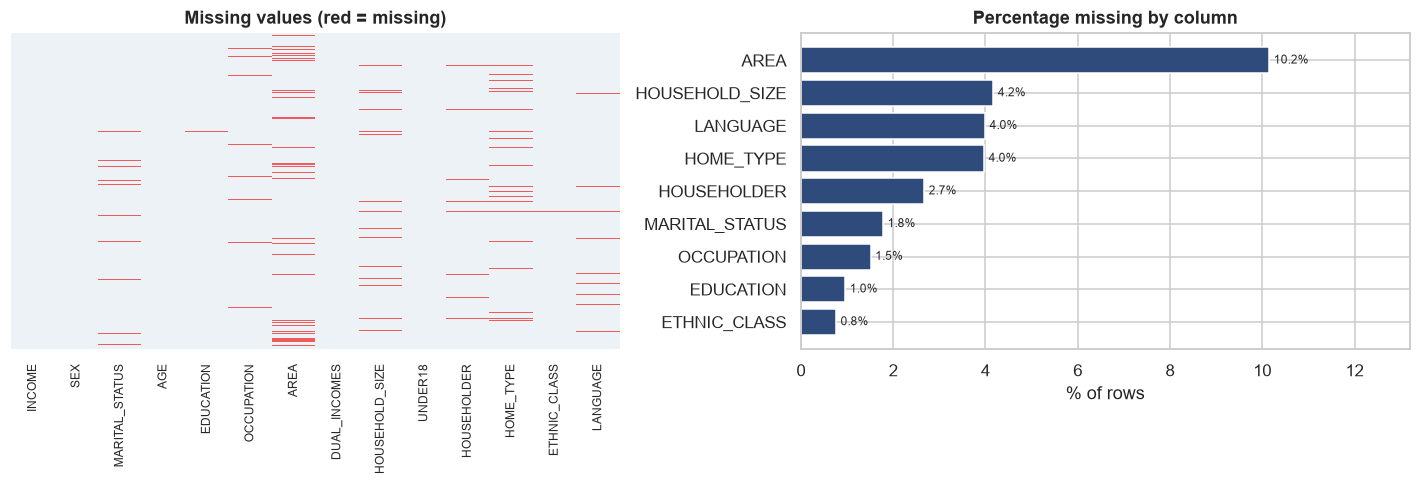

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.heatmap(df.isna(), cbar=False, cmap=ListedColormap(["#EDF2F7", RED]), yticklabels=False, ax=axes[0])
axes[0].set_title("Missing values (red = missing)")
axes[0].tick_params(axis="x", rotation=90, labelsize=8)

bars = axes[1].barh(missing.index[::-1], missing["missing_%"][::-1], color=BLUE)
axes[1].bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
axes[1].set_title("Percentage missing by column")
axes[1].set_xlabel("% of rows")
axes[1].set_xlim(0, missing["missing_%"].max() * 1.3)

plt.tight_layout()
plt.show()

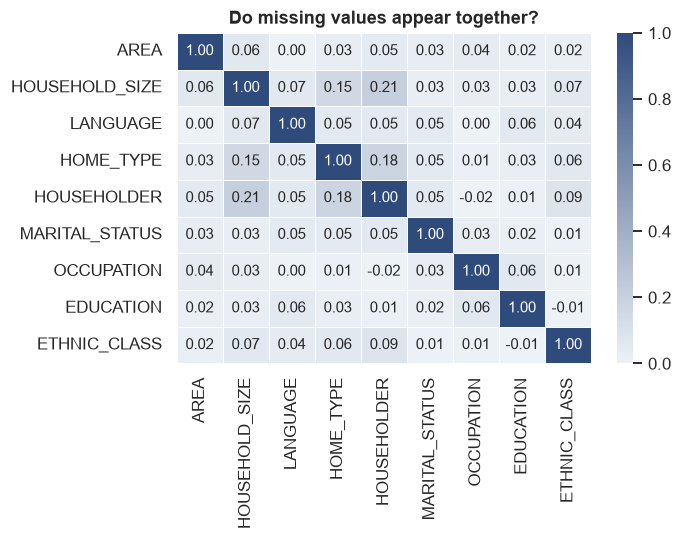

Rows with at least one missing value: 2117
Fully complete rows: 6876


In [9]:
gaps = df[missing.index].isna().astype(int)

plt.figure(figsize=(6.5, 5))
sns.heatmap(gaps.corr(), annot=True, fmt=".2f", cmap=SEQ, vmin=0, vmax=1, linewidths=0.5, linecolor="white")
plt.title("Do missing values appear together?")
plt.tight_layout()
plt.show()

print("Rows with at least one missing value:", (df.isna().sum(axis=1) > 0).sum())
print("Fully complete rows:", (df.isna().sum(axis=1) == 0).sum())

The correlations are mostly low, so the missing values are scattered rather than one whole section being skipped. The three housing columns (`HOUSEHOLD_SIZE`, `HOUSEHOLDER`, `HOME_TYPE`) are the exception: their gaps are weakly linked (0.15 to 0.21), so some respondents skipped the housing questions together.

Dropping every incomplete row would remove 2,117 households (23.5% of the sample), so a mixed approach is used:

- `INCOME` missing - drop the row, since it is the column being studied.
- More than 5% missing - fill with `"Unknown"`, so non-response stays visible.
- 5% or less missing - fill with the mode.

In [10]:
work = df.dropna(subset=["INCOME"]).reset_index(drop=True)

rates = work.isna().mean()
unknown_cols = [c for c in work.columns if rates[c] > 0.05]
mode_cols = [c for c in work.columns if 0 < rates[c] <= 0.05]

for c in unknown_cols:
    work[c] = work[c].fillna("Unknown")
for c in mode_cols:
    work[c] = work[c].fillna(work[c].mode().iat[0])

print("Filled with 'Unknown':", unknown_cols)
print("Filled with mode:", mode_cols)
print("Missing values left:", int(work.isna().sum().sum()))

Filled with 'Unknown': ['AREA']
Filled with mode: ['MARITAL_STATUS', 'EDUCATION', 'OCCUPATION', 'HOUSEHOLD_SIZE', 'HOUSEHOLDER', 'HOME_TYPE', 'ETHNIC_CLASS', 'LANGUAGE']
Missing values left: 0


## **4. Data Cleaning**

Now the values that are present but wrong are checked: extra spaces, a spelling mistake, contradictions between columns, and impossible records.

In [11]:
for c in work.select_dtypes(include="object").columns:
    work[c] = work[c].astype(str).str.strip()

print("Before:")
print(work["EDUCATION"].value_counts().to_string())

work["EDUCATION"] = work["EDUCATION"].replace({"Graduated High Scool": "Graduated High School"})

print()
print("After fixing the spelling:")
print(work["EDUCATION"].value_counts().to_string())

Before:
EDUCATION
1 to 3 years of college    3152
Graduated High Scool       2041
College graduate           1524
Grades 9 to 11             1046
Grad Study                  966
Grade 8 or less             264

After fixing the spelling:
EDUCATION
1 to 3 years of college    3152
Graduated High School      2041
College graduate           1524
Grades 9 to 11             1046
Grad Study                  966
Grade 8 or less             264


`DUAL_INCOMES` has the values `Yes`, `No` and `Not Married`, so it repeats information already present in `MARITAL_STATUS`. Rows where the two disagree are contradictions.

In [12]:
married = work["MARITAL_STATUS"] == "Married"
conflict = married & (work["DUAL_INCOMES"] == "Not Married")

print("Contradictory rows:", conflict.sum())
pd.crosstab(work["MARITAL_STATUS"], work["DUAL_INCOMES"])

Contradictory rows: 93


DUAL_INCOMES,No,Not Married,Yes
MARITAL_STATUS,,,
Divorced,0,875,0
Married,1219,93,2022
Single,45,3727,42
Together,80,441,147
Widowed,0,302,0


In [13]:
work["DUAL_INCOMES_CLEAN"] = work["DUAL_INCOMES"].where(~conflict, "Unclear")
work["DUAL_INCOMES_CLEAN"].value_counts()

DUAL_INCOMES_CLEAN
Not Married    5345
Yes            2211
No             1344
Unclear          93
Name: count, dtype: int64

Instead of guessing which column is correct, these rows are marked `Unclear`. The row is still usable for everything else.

Next, some records are logically impossible: a 14-17 year old cannot be retired, a college graduate, or widowed. These are removed.

In [14]:
teen = work["AGE"] == "14-17"
impossible = teen & (
    work["EDUCATION"].isin(["College graduate", "Grad Study"])
    | work["OCCUPATION"].isin(["Retired", "Military"])
    | work["MARITAL_STATUS"].isin(["Married", "Divorced", "Widowed"])
)

print("Impossible rows found:", impossible.sum())
print(work.loc[impossible, ["AGE", "EDUCATION", "OCCUPATION", "MARITAL_STATUS"]].head().to_string())

work = work.loc[~impossible].reset_index(drop=True)
print()
print("Rows kept:", len(work))

Impossible rows found: 23
        AGE              EDUCATION               OCCUPATION MARITAL_STATUS
54    14-17       College graduate                  Retired        Married
608   14-17         Grades 9 to 11                Homemaker        Married
801   14-17         Grades 9 to 11  Professional/Managerial        Married
1613  14-17  Graduated High School             Sales Worker       Divorced
1668  14-17  Graduated High School                 Military         Single

Rows kept: 8970


In [15]:
print("Exact duplicate rows:", work.duplicated().sum())

Exact duplicate rows: 776


Duplicate rows are kept here. With only 14 broad categorical columns, two different households can genuinely give the same answer to every question, so removing them would delete real respondents.

## **5. Data Transformation**

Each band is replaced by its midpoint and each word is replaced by its number, so the data can be used for statistics and plots. `INCOME`, `AGE` and `EDUCATION` are also set as ordered categories so charts follow the correct order instead of alphabetical order.

The two open bands (`< 10.000` and `75.000+`) are given the working values 5 and 87.5, so any number based on them is an estimate.

In [16]:
income_order = ["-10.000)", "[10.000-15.000)", "[15.000-20.000)", "[20.000-25.000)", "[25.000-30.000)",
                "[30.000-40.000)", "[40.000-50.000)", "[50.000-75.000)", "[75.000-"]
income_label = dict(zip(income_order,
    ["< 10K", "10-15K", "15-20K", "20-25K", "25-30K", "30-40K", "40-50K", "50-75K", "75K +"]))
income_mid = dict(zip(income_order, [5, 12.5, 17.5, 22.5, 27.5, 35, 45, 62.5, 87.5]))

age_order = ["14-17", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
age_mid = dict(zip(age_order, [15.5, 21, 29.5, 39.5, 49.5, 59.5, 70]))

edu_order = ["Grade 8 or less", "Grades 9 to 11", "Graduated High School",
             "1 to 3 years of college", "College graduate", "Grad Study"]
edu_rank = {level: i + 1 for i, level in enumerate(edu_order)}

area_years = {"-1 year": 0.5, "1-3 years": 2, "4-6 years": 5, "7-10 years": 8.5, "10+ years": 12}

words = {"None": 0, "One": 1, "Two": 2, "Three": 3, "Four": 4,
         "Five": 5, "Six": 6, "Seven": 7, "Eight": 8, "Nine or more": 9}

tidy = work.copy()

tidy["INCOME_BAND"] = pd.Categorical(tidy["INCOME"].map(income_label),
                                     categories=[income_label[k] for k in income_order], ordered=True)
tidy["AGE_BAND"] = pd.Categorical(tidy["AGE"], categories=age_order, ordered=True)
tidy["EDU_BAND"] = pd.Categorical(tidy["EDUCATION"], categories=edu_order, ordered=True)

tidy["INCOME_K"] = tidy["INCOME"].map(income_mid)
tidy["AGE_YEARS"] = tidy["AGE"].map(age_mid)
tidy["EDU_RANK"] = tidy["EDUCATION"].map(edu_rank)
tidy["AREA_YEARS"] = tidy["AREA"].map(area_years)
tidy["HH_SIZE"] = tidy["HOUSEHOLD_SIZE"].map(words)
tidy["CHILDREN"] = tidy["UNDER18"].map(words)
tidy["OWNS_HOME"] = (tidy["HOUSEHOLDER"] == "Own").astype(int)

tidy.head(3)

,INCOME,SEX,MARITAL_STATUS,AGE,EDUCATION,OCCUPATION,AREA,DUAL_INCOMES,HOUSEHOLD_SIZE,UNDER18,...,INCOME_BAND,AGE_BAND,EDU_BAND,INCOME_K,AGE_YEARS,EDU_RANK,AREA_YEARS,HH_SIZE,CHILDREN,OWNS_HOME
0,[75.000-,F,Married,45-54,1 to 3 years of college,Homemaker,10+ years,No,Three,None,...,75K +,45-54,1 to 3 years of college,87.5,49.5,4,12.0,3,0,1
1,[75.000-,M,Married,45-54,College graduate,Homemaker,10+ years,No,Five,Two,...,75K +,45-54,College graduate,87.5,49.5,5,12.0,5,2,1
2,[75.000-,F,Married,25-34,College graduate,Professional/Managerial,10+ years,Yes,Three,One,...,75K +,25-34,College graduate,87.5,29.5,5,12.0,3,1,0


In [17]:
numeric_cols = ["INCOME_K", "AGE_YEARS", "EDU_RANK", "AREA_YEARS", "HH_SIZE", "CHILDREN", "OWNS_HOME"]

print("Values that could not be mapped:")
print(tidy[numeric_cols].isna().sum().to_string())

tidy[numeric_cols].describe().T.round(2)

Values that could not be mapped:
INCOME_K        0
AGE_YEARS       0
EDU_RANK        0
AREA_YEARS    909
HH_SIZE         0
CHILDREN        0
OWNS_HOME       0


,count,mean,std,min,25%,50%,75%,max
INCOME_K,8970.0,34.49,25.52,5.0,12.5,27.5,45.0,87.5
AGE_YEARS,8970.0,34.67,15.32,15.5,21.0,29.5,39.5,70.0
EDU_RANK,8970.0,3.84,1.23,1.0,3.0,4.0,5.0,6.0
AREA_YEARS,8061.0,9.34,3.97,0.5,8.5,12.0,12.0,12.0
HH_SIZE,8970.0,2.81,1.51,1.0,2.0,2.0,4.0,9.0
CHILDREN,8970.0,0.66,1.08,0.0,0.0,0.0,1.0,9.0
OWNS_HOME,8970.0,0.36,0.48,0.0,0.0,0.0,1.0,1.0


`AREA_YEARS` is the only column with gaps left, because those rows were filled with `Unknown` in step 3 and no number can be given to them. They are skipped wherever that column is used.

Statistics are now possible on income:

In [18]:
print("Median income:", tidy["INCOME_K"].median(), "K")
print("Mean income:", round(tidy["INCOME_K"].mean(), 2), "K")
print("Standard deviation:", round(tidy["INCOME_K"].std(), 2))
print("Skew:", round(tidy["INCOME_K"].skew(), 2))

Median income: 27.5 K
Mean income: 34.49 K
Standard deviation: 25.52
Skew: 0.7


## **6. Univariate Analysis**

Each variable is looked at on its own. Three plots are given below.

### Plot 1 - Income distribution

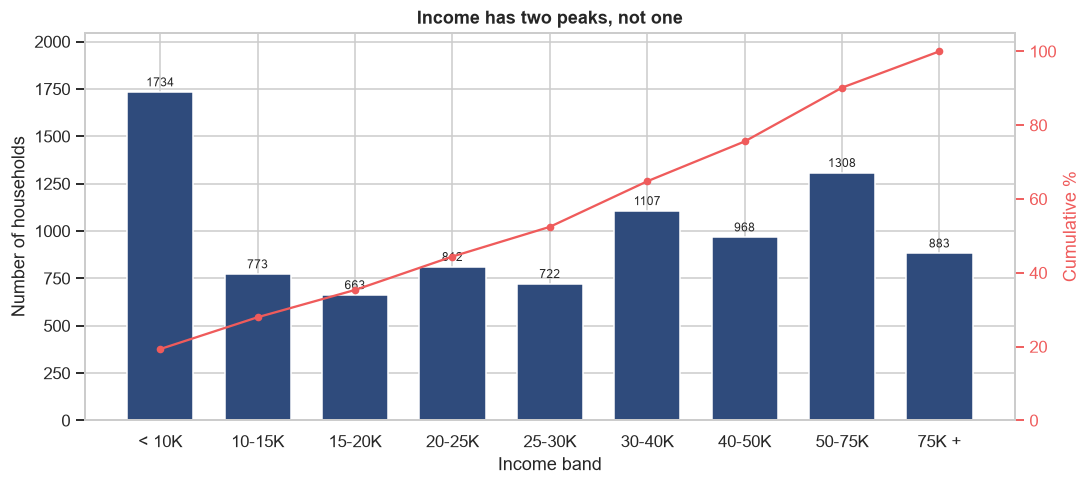

Households below 25K: 44.4 %
Households at 50K or above: 24.4 %


In [19]:
counts = tidy["INCOME_BAND"].value_counts().sort_index()
cumulative = counts.cumsum() / counts.sum() * 100

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(counts.index.astype(str), counts.values, color=BLUE, width=0.68)
ax.bar_label(bars, padding=2, fontsize=8)
ax.set_title("Income has two peaks, not one")
ax.set_xlabel("Income band")
ax.set_ylabel("Number of households")
ax.set_ylim(0, counts.max() * 1.18)

twin = ax.twinx()
twin.plot(counts.index.astype(str), cumulative.values, color=RED, marker="o", markersize=4)
twin.set_ylabel("Cumulative %", color=RED)
twin.tick_params(axis="y", colors=RED)
twin.set_ylim(0, 105)
twin.grid(False)

plt.tight_layout()
plt.show()

print("Households below 25K:", round((tidy["INCOME_K"] < 25).mean() * 100, 1), "%")
print("Households at 50K or above:", round((tidy["INCOME_K"] >= 50).mean() * 100, 1), "%")

The `< 10K` band and the `75K +` band are both large, so the distribution has two peaks. The reason for the low peak is checked in the bivariate section.

### Plot 2 - Age, education, occupation and home type

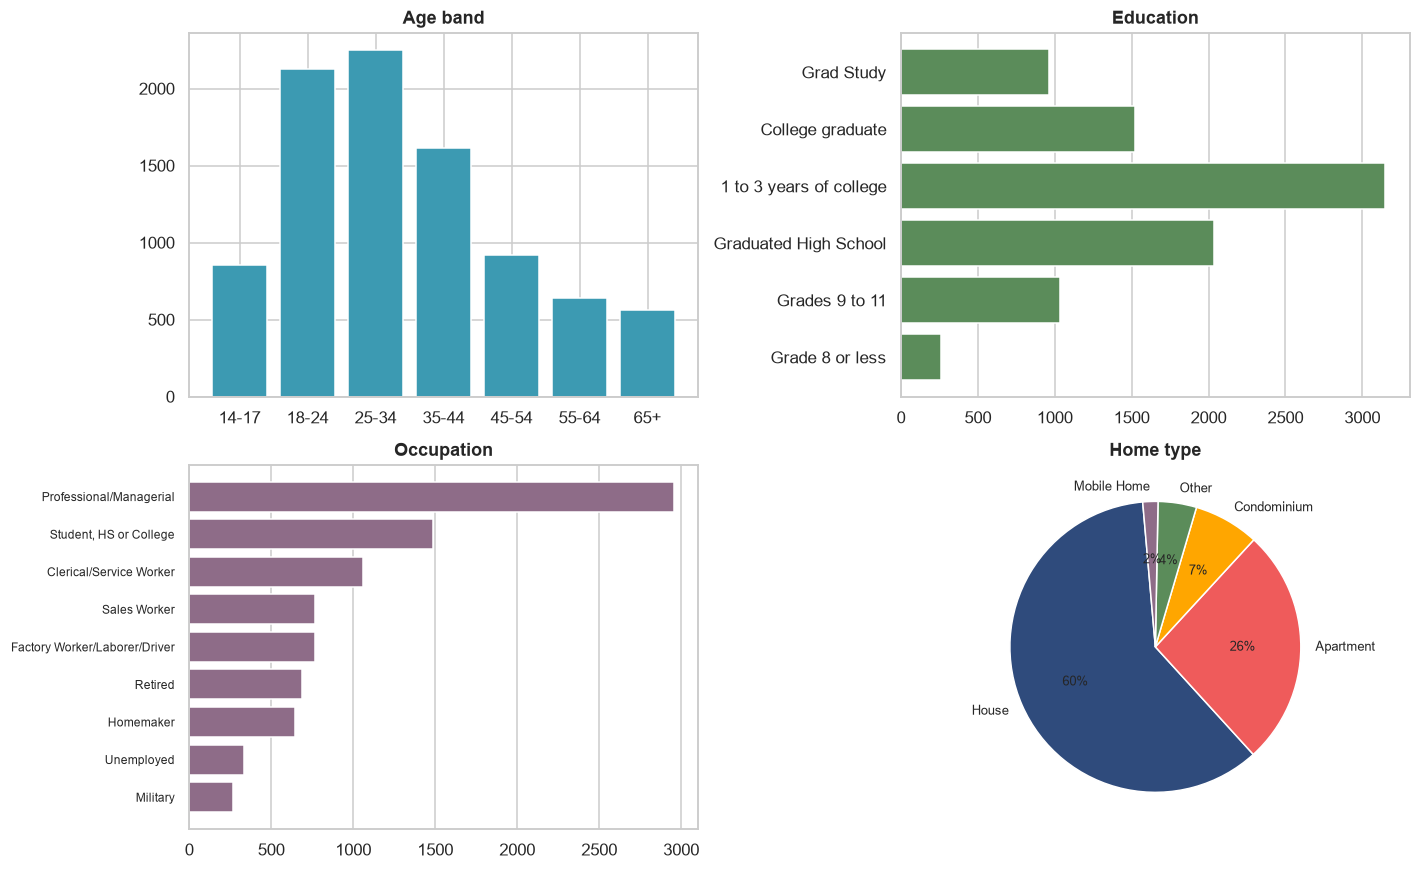

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

age_counts = tidy["AGE_BAND"].value_counts().sort_index()
axes[0, 0].bar(age_counts.index.astype(str), age_counts.values, color=TEAL)
axes[0, 0].set_title("Age band")

edu_counts = tidy["EDU_BAND"].value_counts().sort_index()
axes[0, 1].barh(edu_counts.index.astype(str), edu_counts.values, color=GREEN)
axes[0, 1].set_title("Education")
axes[0, 1].grid(axis="y", visible=False)

occ_counts = tidy["OCCUPATION"].value_counts().sort_values()
axes[1, 0].barh(occ_counts.index.astype(str), occ_counts.values, color=PURPLE)
axes[1, 0].set_title("Occupation")
axes[1, 0].grid(axis="y", visible=False)
axes[1, 0].tick_params(axis="y", labelsize=8)

home_counts = tidy["HOME_TYPE"].value_counts()
axes[1, 1].pie(home_counts.values, labels=home_counts.index.astype(str), autopct="%1.0f%%",
               colors=PALETTE, startangle=95, textprops={"fontsize": 8.5})
axes[1, 1].set_title("Home type")

plt.tight_layout()
plt.show()

### Plot 3 - Income and household size

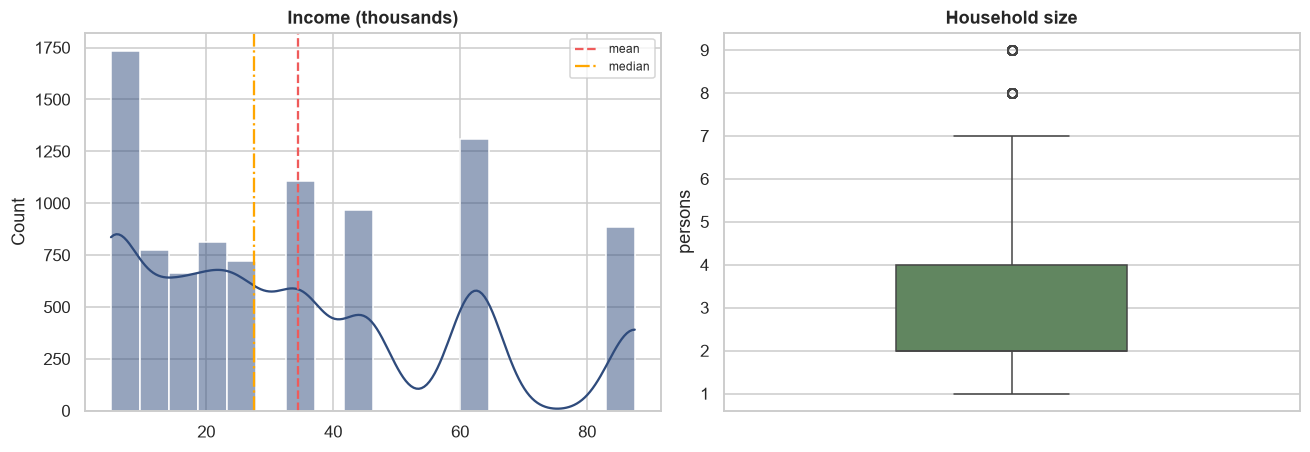

Most common household size: 2 persons


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.histplot(tidy["INCOME_K"], bins=18, kde=True, color=BLUE, edgecolor="white", ax=axes[0])
axes[0].axvline(tidy["INCOME_K"].mean(), color=RED, linestyle="--", label="mean")
axes[0].axvline(tidy["INCOME_K"].median(), color=GOLD, linestyle="-.", label="median")
axes[0].set_title("Income (thousands)")
axes[0].set_xlabel("")
axes[0].legend(fontsize=8)

sns.boxplot(y=tidy["HH_SIZE"], color=GREEN, width=0.4, ax=axes[1])
axes[1].set_title("Household size")
axes[1].set_ylabel("persons")

plt.tight_layout()
plt.show()

print("Most common household size:", int(tidy["HH_SIZE"].mode().iat[0]), "persons")

The mean is higher than the median, which means a small number of high earners pull the average up.

## **7. Bivariate Analysis**

Income is now compared against other columns. Three plots are given below.

### Plot 4 - Income and education

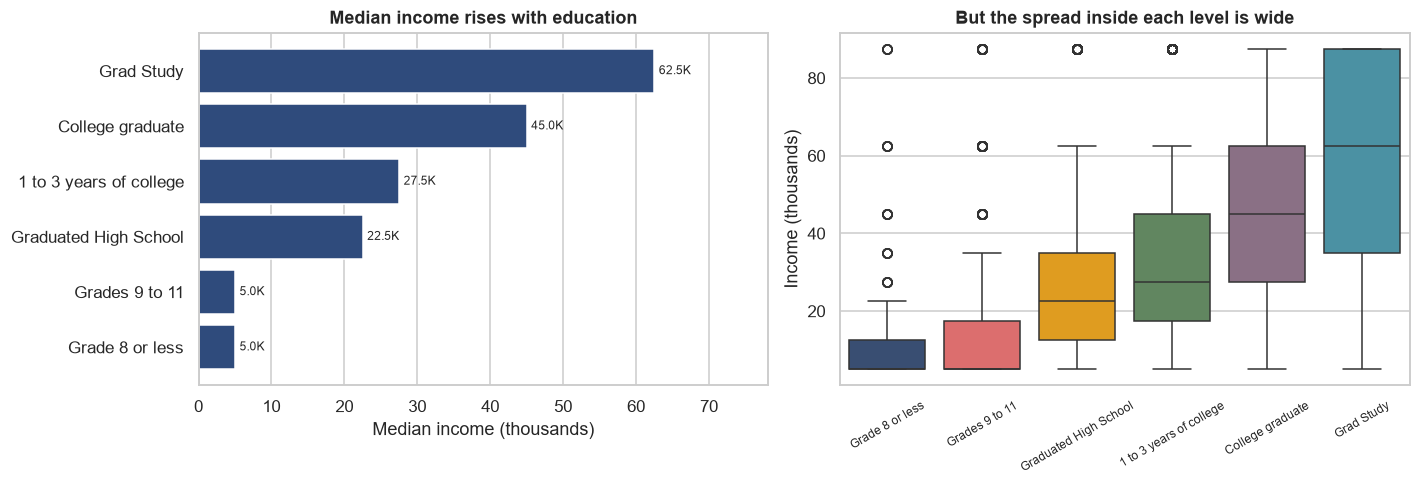

Spearman correlation between education rank and income: 0.452


In [22]:
edu_median = tidy.groupby("EDU_BAND", observed=True)["INCOME_K"].median()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bars = axes[0].barh(edu_median.index.astype(str), edu_median.values, color=BLUE)
axes[0].bar_label(bars, fmt="%.1fK", padding=3, fontsize=8)
axes[0].set_title("Median income rises with education")
axes[0].set_xlabel("Median income (thousands)")
axes[0].set_xlim(0, edu_median.max() * 1.25)
axes[0].grid(axis="y", visible=False)

sns.boxplot(data=tidy, x="EDU_BAND", y="INCOME_K", palette=PALETTE, ax=axes[1])
axes[1].set_title("But the spread inside each level is wide")
axes[1].set_xlabel("")
axes[1].set_ylabel("Income (thousands)")
axes[1].tick_params(axis="x", rotation=30, labelsize=8)

plt.tight_layout()
plt.show()

print("Spearman correlation between education rank and income:",
      round(tidy["EDU_RANK"].corr(tidy["INCOME_K"], method="spearman"), 3))

Income increases at every education level, but the boxes overlap a lot, so education shifts income on average without deciding it for any one household.

### Plot 5 - Income across age groups

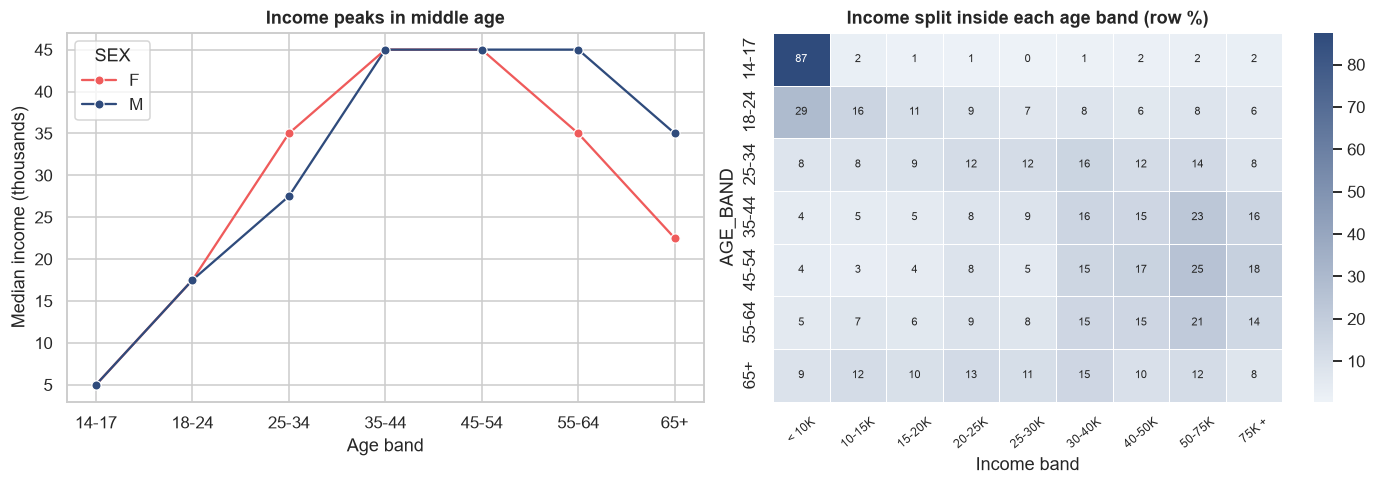

In [23]:
life = tidy.groupby(["AGE_BAND", "SEX"], observed=True)["INCOME_K"].median().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.lineplot(data=life, x="AGE_BAND", y="INCOME_K", hue="SEX", marker="o", palette=[RED, BLUE], ax=axes[0])
axes[0].set_title("Income peaks in middle age")
axes[0].set_xlabel("Age band")
axes[0].set_ylabel("Median income (thousands)")

share = pd.crosstab(tidy["AGE_BAND"], tidy["INCOME_BAND"], normalize="index") * 100
sns.heatmap(share, cmap=SEQ, annot=True, fmt=".0f", linewidths=0.5, linecolor="white",
            annot_kws={"size": 7}, ax=axes[1])
axes[1].set_title("Income split inside each age band (row %)")
axes[1].set_xlabel("Income band")
axes[1].tick_params(axis="x", rotation=40, labelsize=8)

plt.tight_layout()
plt.show()

This explains the low peak seen in Plot 1. Most of the `< 10K` households are in the 14-17 and 18-24 age bands, so they are students living with family, not low-earning workers. Income then rises till 35-54 and falls after 65.

### Plot 6 - Dual incomes and home ownership

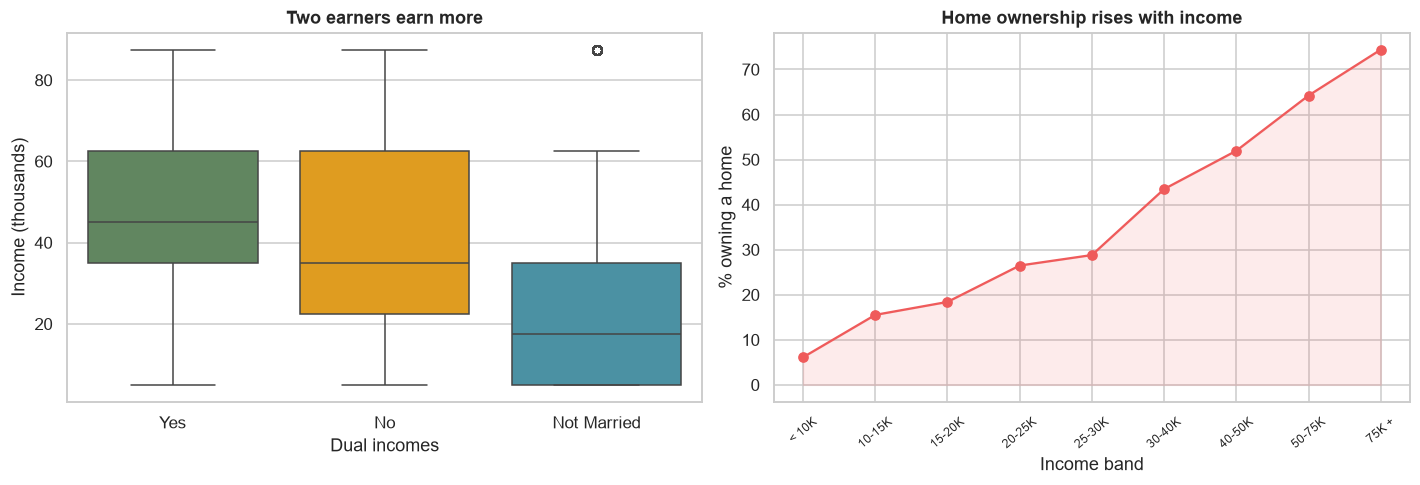

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

dual = tidy[tidy["DUAL_INCOMES_CLEAN"].isin(["Yes", "No", "Not Married"])]
sns.boxplot(data=dual, x="DUAL_INCOMES_CLEAN", y="INCOME_K", order=["Yes", "No", "Not Married"],
            palette=[GREEN, GOLD, TEAL], ax=axes[0])
axes[0].set_title("Two earners earn more")
axes[0].set_xlabel("Dual incomes")
axes[0].set_ylabel("Income (thousands)")

own = tidy.groupby("INCOME_BAND", observed=True)["OWNS_HOME"].mean().mul(100)
axes[1].plot(own.index.astype(str), own.values, color=RED, marker="o")
axes[1].fill_between(own.index.astype(str), own.values, color=RED, alpha=0.12)
axes[1].set_title("Home ownership rises with income")
axes[1].set_xlabel("Income band")
axes[1].set_ylabel("% owning a home")
axes[1].tick_params(axis="x", rotation=40, labelsize=8)

plt.tight_layout()
plt.show()

## **8. Multivariate Analysis**

Three or more variables are now looked at together. Three plots are given below.

### Plot 7 - Correlation between all numeric columns

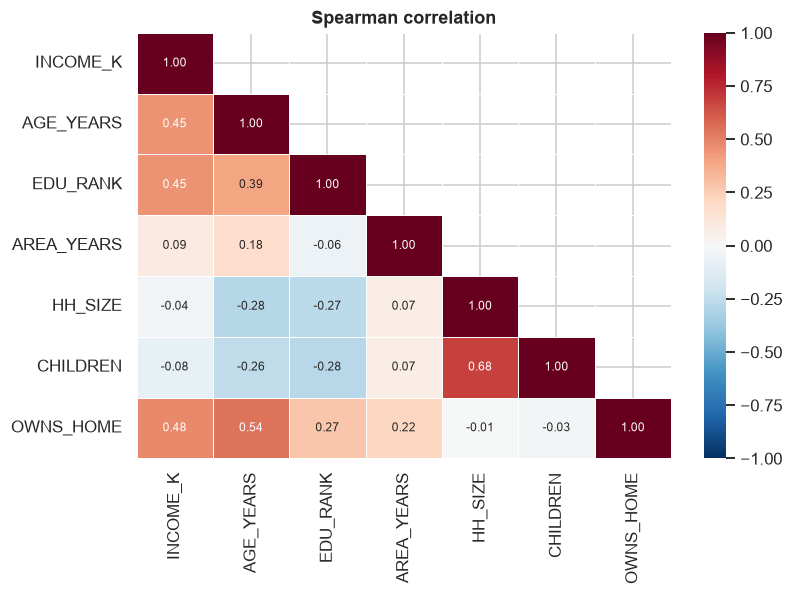

Correlation with income, strongest first:
OWNS_HOME     0.481
EDU_RANK      0.452
AGE_YEARS     0.446
AREA_YEARS    0.087
CHILDREN      0.082
HH_SIZE       0.035


In [25]:
corr = tidy[numeric_cols].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(7.5, 5.5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor="white", annot_kws={"size": 8})
plt.title("Spearman correlation")
plt.tight_layout()
plt.show()

print("Correlation with income, strongest first:")
print(corr["INCOME_K"].drop("INCOME_K").abs().sort_values(ascending=False).round(3).to_string())

Spearman is used instead of Pearson because these values come from ordered bands, so ranks are more reliable than the exact midpoints chosen.

### Plot 8 - Education and occupation together

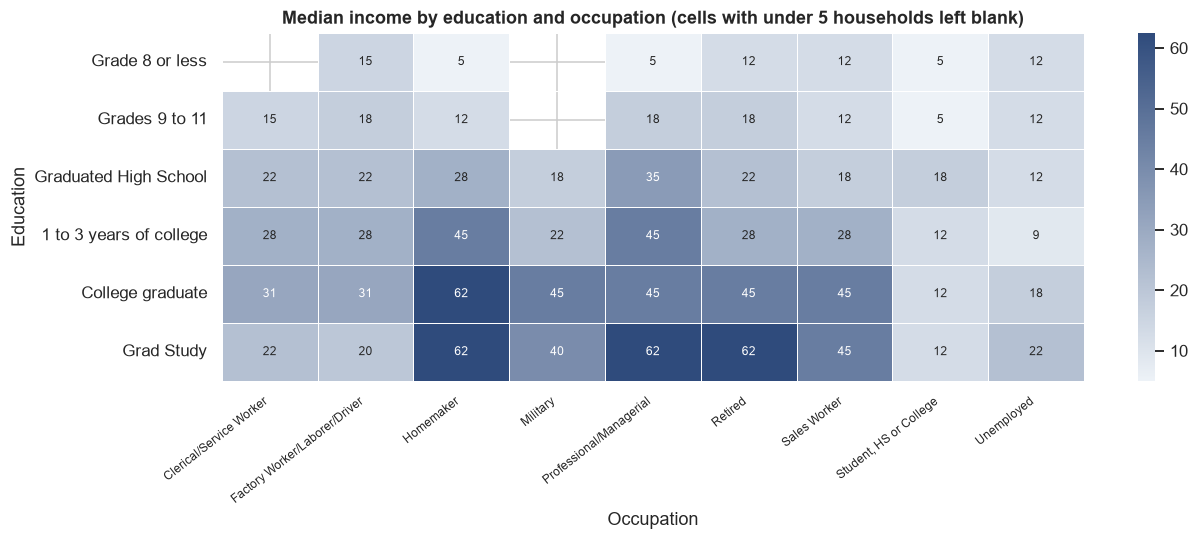

In [26]:
grid = tidy.pivot_table(index="EDU_BAND", columns="OCCUPATION", values="INCOME_K",
                        aggfunc="median", observed=True)
count = tidy.pivot_table(index="EDU_BAND", columns="OCCUPATION", values="INCOME_K",
                         aggfunc="size", observed=True)
grid = grid.where(count >= 5)

plt.figure(figsize=(12, 5))
sns.heatmap(grid, cmap=SEQ, annot=True, fmt=".0f", linewidths=0.5, linecolor="white", annot_kws={"size": 8})
plt.title("Median income by education and occupation (cells with under 5 households left blank)")
plt.xlabel("Occupation")
plt.ylabel("Education")
plt.xticks(rotation=38, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

Cells built from fewer than 5 households are left blank, because a median from 2 rows is not reliable enough to colour the same way as one from 80 rows.

The highest values sit where high education meets professional work, so the two factors add up rather than working separately.

### Plot 9 - Age, dual income and household size together

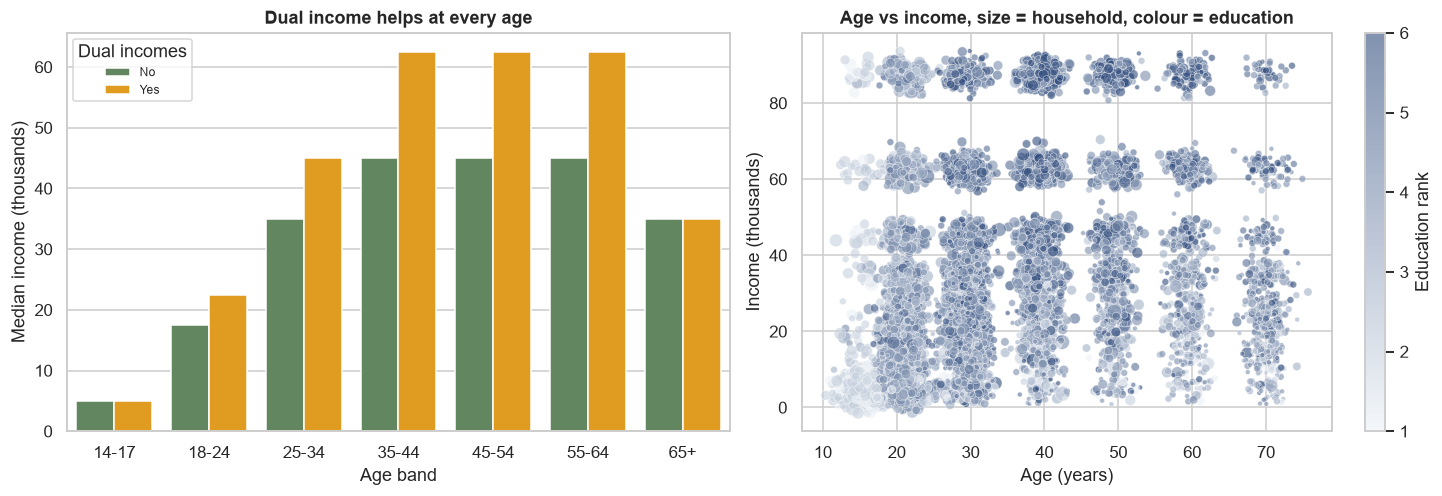

In [27]:
combo = (tidy[tidy["DUAL_INCOMES_CLEAN"].isin(["Yes", "No"])]
         .groupby(["AGE_BAND", "DUAL_INCOMES_CLEAN"], observed=True)["INCOME_K"]
         .median().reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

sns.barplot(data=combo, x="AGE_BAND", y="INCOME_K", hue="DUAL_INCOMES_CLEAN",
            palette=[GREEN, GOLD], errorbar=None, ax=axes[0])
axes[0].set_title("Dual income helps at every age")
axes[0].set_xlabel("Age band")
axes[0].set_ylabel("Median income (thousands)")
axes[0].legend(title="Dual incomes", fontsize=8)

rng = np.random.default_rng(23)
sample = tidy.dropna(subset=["AGE_YEARS", "INCOME_K", "HH_SIZE", "EDU_RANK"])
x = sample["AGE_YEARS"] + rng.normal(0, 1.5, len(sample))
y = sample["INCOME_K"] + rng.normal(0, 2.2, len(sample))

points = axes[1].scatter(x, y, c=sample["EDU_RANK"], s=sample["HH_SIZE"] * 10,
                         cmap=SEQ, alpha=0.6, edgecolor="white", linewidth=0.4)
axes[1].set_title("Age vs income, size = household, colour = education")
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("Income (thousands)")
plt.colorbar(points, ax=axes[1], label="Education rank")

plt.tight_layout()
plt.show()

A small random jitter is added to the scatter points only so they do not stack on top of each other. The actual values are unchanged.

## **9. Conclusion**

**About the data**

1. No column was numeric, so the transformation step was needed before any analysis could be done.
2. Missing values were mostly scattered, except in the housing columns where the same respondents left several fields blank.
3. Four problems were found and fixed: the word `None` in `UNDER18` (no children) being read as missing, a spelling mistake in `EDUCATION`, contradictions between `MARITAL_STATUS` and `DUAL_INCOMES`, and impossible records such as retired teenagers.

**About the households**

4. Income has two peaks. The large `< 10K` group is mainly students living with family, which was only visible after comparing income with age.
5. Home ownership, education and age are the three variables most linked with income (Spearman 0.48, 0.45 and 0.45). Ownership is partly a result of income, so among the background factors education matters most: median income rises at every level, though the spread within each level is wide.
6. Dual income gives a clear advantage in every age group.
7. Education and occupation combine, with the highest incomes where advanced education meets professional work.

**Limitations**

- All income and age values are band midpoints, so every number is an estimate.
- `ETHNIC_CLASS` and `LANGUAGE` are almost entirely one category, so no group comparison was done on them.
- These are only associations within one survey. No cause and effect is claimed.

---
# **Phase 2 - Statistical Analysis and Clustering**

Phase 2 continues from the cleaned and transformed table `tidy` built in Phase 1, so the Phase 1 cells above must be run first (**Runtime → Run all**).

| Section | Topic | What it answers |
|---|---|---|
| 10 | 1D statistical analysis | What does each variable look like on its own? |
| 11 | 2D statistical analysis | How strongly are two variables related, and is it significant? |
| 12 | 3D statistical analysis | Does a relationship change once a third variable is considered? |
| 13 | K-Means clustering | Which groups of similar households exist? |
| 14 | Hierarchical clustering | Do the same groups appear with a different method? |
| 15 | Conclusion | Summary of Phase 2 |

A significance level of **α = 0.05** is used for every hypothesis test.

In [28]:
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)

data = tidy.copy()
data["DUAL"] = (data["DUAL_INCOMES_CLEAN"] == "Yes").astype(int)

cont_cols = ["INCOME_K", "AGE_YEARS", "EDU_RANK", "AREA_YEARS", "HH_SIZE", "CHILDREN"]
cat_cols = ["SEX", "MARITAL_STATUS", "OCCUPATION", "HOUSEHOLDER", "HOME_TYPE",
            "DUAL_INCOMES_CLEAN", "ETHNIC_CLASS", "LANGUAGE"]


def pval(p):
    """Readable p-value for tables."""
    return "< 0.001" if p < 0.001 else f"{p:.3f}"


def strength(r):
    """Common rule of thumb for the size of a correlation."""
    r = abs(r)
    return "very weak" if r < 0.1 else "weak" if r < 0.3 else "moderate" if r < 0.5 else "strong"


print("Rows:", len(data))
print("Numeric variables:", cont_cols)
print("Categorical variables:", cat_cols)

Rows: 8970
Numeric variables: ['INCOME_K', 'AGE_YEARS', 'EDU_RANK', 'AREA_YEARS', 'HH_SIZE', 'CHILDREN']
Categorical variables: ['SEX', 'MARITAL_STATUS', 'OCCUPATION', 'HOUSEHOLDER', 'HOME_TYPE', 'DUAL_INCOMES_CLEAN', 'ETHNIC_CLASS', 'LANGUAGE']


## **10. 1D Statistical Analysis (one variable at a time)**

1D analysis summarises a single variable. For numeric variables four families of measures are used:

- **Central tendency**: where the centre of the data is (mean, median, mode, trimmed mean).
- **Dispersion**: how spread out the values are (range, variance, standard deviation, IQR, MAD, coefficient of variation).
- **Shape**: whether the distribution is lopsided (skewness) or has heavy tails (kurtosis).
- **Position**: percentiles, the five-number summary and outliers.

Then normality is tested, confidence intervals are built, and categorical variables are summarised with frequencies and entropy.

### 10.1 Central tendency

In [29]:
central = pd.DataFrame({
    "mean": data[cont_cols].mean(),
    "median": data[cont_cols].median(),
    "mode": data[cont_cols].mode().iloc[0],
    "trimmed_mean_10%": [stats.trim_mean(data[c].dropna(), 0.1) for c in cont_cols],
}).round(2)
central

,mean,median,mode,trimmed_mean_10%
INCOME_K,34.49,27.5,5.0,31.60
AGE_YEARS,34.67,29.5,29.5,33.11
EDU_RANK,3.84,4.0,4.0,3.83
AREA_YEARS,9.34,12.0,12.0,9.99
HH_SIZE,2.81,2.0,2.0,2.65
CHILDREN,0.66,0.0,0.0,0.45


- For income, age, household size and children the **mean is above the median**, the usual sign of a right-skewed distribution. For income the order is mean (34.5K) > median (27.5K) > mode (5K).
- The 10% trimmed mean ignores the top and bottom 10% of values. It is lower than the mean for income (31.6K), so the high earners pull the ordinary mean up.
- `AREA_YEARS` is the opposite (mean 9.3 < median 12). Most people have lived in their area for 10+ years, and the few newcomers pull the mean down.
- The median number of children is 0, because 64% of households have nobody under 18.

### 10.2 Dispersion (spread)

- **Variance / standard deviation**: average squared / typical distance from the mean.
- **IQR**: width of the middle 50% of the data, not affected by extreme values.
- **MAD**: median absolute deviation from the median, another robust spread measure.
- **Coefficient of variation (CV)**: standard deviation as a % of the mean, so spreads of variables in different units can be compared.

In [30]:
dispersion = pd.DataFrame({
    "min": data[cont_cols].min(),
    "max": data[cont_cols].max(),
    "range": data[cont_cols].max() - data[cont_cols].min(),
    "variance": data[cont_cols].var(),
    "std": data[cont_cols].std(),
    "IQR": data[cont_cols].quantile(0.75) - data[cont_cols].quantile(0.25),
    "MAD": [stats.median_abs_deviation(data[c].dropna()) for c in cont_cols],
    "CV_%": data[cont_cols].std() / data[cont_cols].mean() * 100,
    "std_error": data[cont_cols].sem(),
}).round(2)
dispersion

,min,max,range,variance,std,IQR,MAD,CV_%,std_error
INCOME_K,5.0,87.5,82.5,651.12,25.52,32.5,17.5,73.98,0.27
AGE_YEARS,15.5,70.0,54.5,234.83,15.32,18.5,10.0,44.20,0.16
EDU_RANK,1.0,6.0,5.0,1.53,1.23,2.0,1.0,32.17,0.01
AREA_YEARS,0.5,12.0,11.5,15.78,3.97,3.5,0.0,42.52,0.04
HH_SIZE,1.0,9.0,8.0,2.29,1.51,2.0,1.0,53.72,0.02
CHILDREN,0.0,9.0,9.0,1.17,1.08,1.0,0.0,162.81,0.01


- Income has the largest spread (SD 25.5K, CV 74%). A typical household is 17.5K away from the median income (MAD).
- `CHILDREN` has the highest CV (163%): most households have none and a few have many.
- `EDU_RANK` has the lowest CV (32%), so education is the most similar variable across households.
- `AREA_YEARS` has MAD = 0 because more than half the answers are the same value (10+ years).
- The standard errors are small (0.27K for income) because the sample is large, so the means are estimated precisely.

### 10.3 Shape - skewness and kurtosis

- **Skewness** = 0 for a symmetric distribution, > 0 when the right tail is longer, < 0 when the left tail is longer.
- **Excess kurtosis** = 0 for a normal distribution, > 0 for heavier tails (more extreme values), < 0 for lighter tails.

In [31]:
def skew_label(s):
    if abs(s) < 0.5:
        return "roughly symmetric"
    side = "right" if s > 0 else "left"
    return f"moderately {side}-skewed" if abs(s) < 1 else f"highly {side}-skewed"


def kurt_label(k):
    if abs(k) < 0.5:
        return "normal-like tails"
    return "heavy tails (leptokurtic)" if k > 0 else "light tails (platykurtic)"


shape = pd.DataFrame({
    "skewness": data[cont_cols].skew(),
    "excess_kurtosis": data[cont_cols].kurt(),
}).round(2)
shape["skew_meaning"] = shape["skewness"].apply(skew_label)
shape["kurtosis_meaning"] = shape["excess_kurtosis"].apply(kurt_label)
shape

,skewness,excess_kurtosis,skew_meaning,kurtosis_meaning
INCOME_K,0.70,-0.54,moderately right-skewed,light tails (platykurtic)
AGE_YEARS,0.80,-0.26,moderately right-skewed,normal-like tails
EDU_RANK,-0.09,-0.43,roughly symmetric,normal-like tails
AREA_YEARS,-1.10,-0.42,highly left-skewed,normal-like tails
HH_SIZE,1.09,1.47,highly right-skewed,heavy tails (leptokurtic)
CHILDREN,2.01,5.29,highly right-skewed,heavy tails (leptokurtic)


- **Income and age are moderately right-skewed**: there are many young, low-income households and fewer older, high-income ones. Income also has light tails (negative kurtosis) because the top band is capped at "75K+", so extreme values cannot appear.
- **Household size and children are highly right-skewed with heavy tails**: most households are small, but a few very large ones stretch the right tail.
- **`AREA_YEARS` is highly left-skewed**, since most people have lived in their area for over 10 years.
- **Education** is the only roughly symmetric variable.

### 10.4 Position - percentiles and outliers

Outliers are checked with two rules:

- **IQR rule**: a value below Q1 − 1.5·IQR or above Q3 + 1.5·IQR.
- **z-score rule**: a value more than 3 standard deviations from the mean.

In [32]:
percentiles = data[cont_cols].quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T
percentiles.columns = ["P1", "P5", "P10", "Q1", "Median", "Q3", "P90", "P95", "P99"]
percentiles

,P1,P5,P10,Q1,Median,Q3,P90,P95,P99
INCOME_K,5.0,5.0,5.0,12.5,27.5,45.0,62.5,87.50,87.5
AGE_YEARS,15.5,15.5,21.0,21.0,29.5,39.5,59.5,70.00,70.0
EDU_RANK,1.0,2.0,2.0,3.0,4.0,5.0,6.0,6.00,6.0
AREA_YEARS,0.5,2.0,2.0,8.5,12.0,12.0,12.0,12.00,12.0
HH_SIZE,1.0,1.0,1.0,2.0,2.0,4.0,5.0,5.55,8.0
CHILDREN,0.0,0.0,0.0,0.0,0.0,1.0,2.0,3.00,4.0


In [33]:
rows = []
for c in cont_cols:
    x = data[c].dropna()
    q1, q3 = x.quantile([0.25, 0.75])
    low, high = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    iqr_out = (x < low) | (x > high)
    rows.append({
        "variable": c,
        "lower_fence": low,
        "upper_fence": high,
        "IQR_outliers": int(iqr_out.sum()),
        "IQR_outliers_%": iqr_out.mean() * 100,
        "z>3_outliers": int((np.abs(stats.zscore(x)) > 3).sum()),
    })

outliers = pd.DataFrame(rows).set_index("variable").round(2)
outliers

,lower_fence,upper_fence,IQR_outliers,IQR_outliers_%,z>3_outliers
variable,,,,,
INCOME_K,-36.25,93.75,0,0.00,0
AGE_YEARS,-6.75,67.25,560,6.24,0
EDU_RANK,0.00,8.00,0,0.00,0
AREA_YEARS,3.25,17.25,1309,16.24,0
HH_SIZE,-1.00,7.00,107,1.19,107
CHILDREN,-1.50,2.50,609,6.79,201


- Income and education have **no outliers** under either rule, because they are limited to fixed bands.
- The IQR rule flags 16% of `AREA_YEARS` (under 4 years in the area) and 6% of `AGE_YEARS` (the 65+ band), but none of these is beyond 3 standard deviations. They are ordinary answer bands, and the IQR rule over-flags data squeezed into a few bands like this.
- `HH_SIZE` (107 households with 8+ people) and `CHILDREN` (201 households with 4+ children) have real extreme values under both rules.
- These are genuine large families, not data errors, so they are **kept**. They are only 1-2% of the rows.

### 10.5 Normality tests

Many classical tests assume normal data, so each variable is tested.

- H₀: the variable is normally distributed.
- **D'Agostino-Pearson K²** uses skewness and kurtosis together and works on the full data.
- **Shapiro-Wilk** is more powerful but is only reliable up to 5,000 values, so it is run on a random sample of 5,000 rows.

In [34]:
sample5k = data.sample(5000, random_state=23)

rows = []
for c in cont_cols:
    k2, p_k2 = stats.normaltest(data[c].dropna())
    w, p_w = stats.shapiro(sample5k[c].dropna())
    rows.append({
        "variable": c,
        "K2_statistic": round(k2, 1),
        "K2_p": pval(p_k2),
        "Shapiro_W": round(w, 3),
        "Shapiro_p": pval(p_w),
        "normal?": "yes" if min(p_k2, p_w) > 0.05 else "no",
    })

normality = pd.DataFrame(rows).set_index("variable")
normality

,K2_statistic,K2_p,Shapiro_W,Shapiro_p,normal?
variable,,,,,
INCOME_K,809.5,< 0.001,0.894,< 0.001,no
AGE_YEARS,789.0,< 0.001,0.890,< 0.001,no
EDU_RANK,124.9,< 0.001,0.931,< 0.001,no
AREA_YEARS,1202.7,< 0.001,0.671,< 0.001,no
HH_SIZE,1489.7,< 0.001,0.885,< 0.001,no
CHILDREN,3703.8,< 0.001,0.666,< 0.001,no


### Plot 10 - Q-Q plots

A Q-Q plot puts the sorted data against the values a perfect normal distribution would give. Normal data falls on the red line.

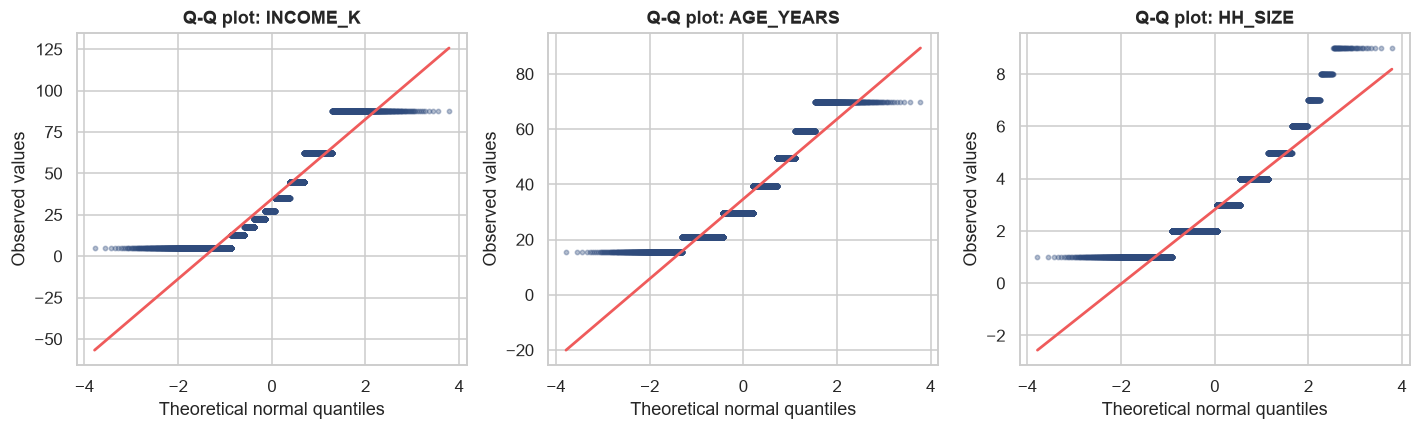

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, c in zip(axes, ["INCOME_K", "AGE_YEARS", "HH_SIZE"]):
    (theory, ordered), (slope, intercept, _) = stats.probplot(data[c], dist="norm")
    ax.scatter(theory, ordered, s=8, color=BLUE, alpha=0.35)
    ax.plot(theory, slope * theory + intercept, color=RED, linewidth=1.8)
    ax.set_title(f"Q-Q plot: {c}")
    ax.set_xlabel("Theoretical normal quantiles")
    ax.set_ylabel("Observed values")

plt.tight_layout()
plt.show()

Every p-value is below 0.001, so H₀ is rejected for all six variables: **none of them is normally distributed**. The Q-Q plots show why. The points form flat steps because the values come from bands, and they bend away from the line at the ends because of the skew.

For this reason the rank-based tests (Spearman, Kendall, Mann-Whitney, Kruskal-Wallis) are reported next to the classical ones in the following sections.

### 10.6 Confidence intervals

A 95% confidence interval gives a range that is expected to contain the true population value in 95% of repeated samples.

- For a **mean**: x̄ ± t · s/√n
- For a **proportion**: p ± z · √(p(1−p)/n)

In [36]:
def mean_ci(x, level=0.95):
    x = x.dropna()
    t_crit = stats.t.ppf((1 + level) / 2, df=len(x) - 1)
    return x.mean(), x.mean() - t_crit * x.sem(), x.mean() + t_crit * x.sem()


def prop_ci(flags, level=0.95):
    p, n = flags.mean(), len(flags)
    z = stats.norm.ppf((1 + level) / 2)
    half = z * np.sqrt(p * (1 - p) / n)
    return p * 100, (p - half) * 100, (p + half) * 100


ci = pd.DataFrame(
    [mean_ci(data["INCOME_K"]), mean_ci(data["AGE_YEARS"]), mean_ci(data["HH_SIZE"]),
     prop_ci(data["INCOME_K"] >= 50), prop_ci(data["OWNS_HOME"] == 1), prop_ci(data["SEX"] == "F")],
    index=["Mean income (K)", "Mean age (years)", "Mean household size",
           "% earning 50K+", "% owning their home", "% women"],
    columns=["estimate", "95% CI lower", "95% CI upper"],
).round(2)
ci

,estimate,95% CI lower,95% CI upper
Mean income (K),34.49,33.96,35.02
Mean age (years),34.67,34.36,34.99
Mean household size,2.81,2.78,2.85
% earning 50K+,24.43,23.54,25.31
% owning their home,36.25,35.26,37.25
% women,54.69,53.66,55.72


Because the sample is large the intervals are narrow. With 95% confidence the true mean income is between **33.96K and 35.02K**, and **23.5% to 25.3%** of households earn 50K or more. The interval for women (53.7% to 55.7%) does not include 50%, which the next test confirms.

### 10.7 Categorical variables

For categorical variables the mode and frequencies describe the centre. **Entropy** describes the spread: it is 0 when every row is in one category. **Evenness** divides entropy by its maximum, so 1 means all categories are equally common.

In [37]:
rows = []
for c in cat_cols:
    p = data[c].value_counts(normalize=True)
    entropy = -(p * np.log2(p)).sum()
    rows.append({
        "variable": c,
        "categories": len(p),
        "mode": p.index[0],
        "mode_%": p.iloc[0] * 100,
        "entropy_bits": entropy,
        "evenness_0_to_1": entropy / np.log2(len(p)),
    })

cat_summary = pd.DataFrame(rows).set_index("variable").round(2)
cat_summary.sort_values("evenness_0_to_1")

,categories,mode,mode_%,entropy_bits,evenness_0_to_1
variable,,,,,
LANGUAGE,3,English,90.69,0.53,0.33
ETHNIC_CLASS,8,White,65.45,1.67,0.56
HOME_TYPE,5,House,60.37,1.52,0.65
DUAL_INCOMES_CLEAN,4,Not Married,59.44,1.42,0.71
MARITAL_STATUS,5,Single,42.39,1.83,0.79
OCCUPATION,9,Professional/Managerial,32.93,2.81,0.89
HOUSEHOLDER,3,Rent,43.47,1.52,0.96
SEX,2,F,54.69,0.99,0.99


A **chi-square goodness-of-fit test** checks whether a single categorical variable matches an expected split. Here H₀ is that the sample has equal numbers of men and women.

In [38]:
sex_counts = data["SEX"].value_counts()
chi2, p = stats.chisquare(sex_counts)

print(sex_counts.to_string())
print()
print(f"Chi-square = {chi2:.2f}, p-value = {pval(p)}")
print("Reject H0 (the split is not 50/50)" if p < 0.05 else "Fail to reject H0")

SEX
F    4906
M    4064

Chi-square = 79.04, p-value = < 0.001
Reject H0 (the split is not 50/50)


### Plot 11 - All numeric variables on one scale, and categorical evenness

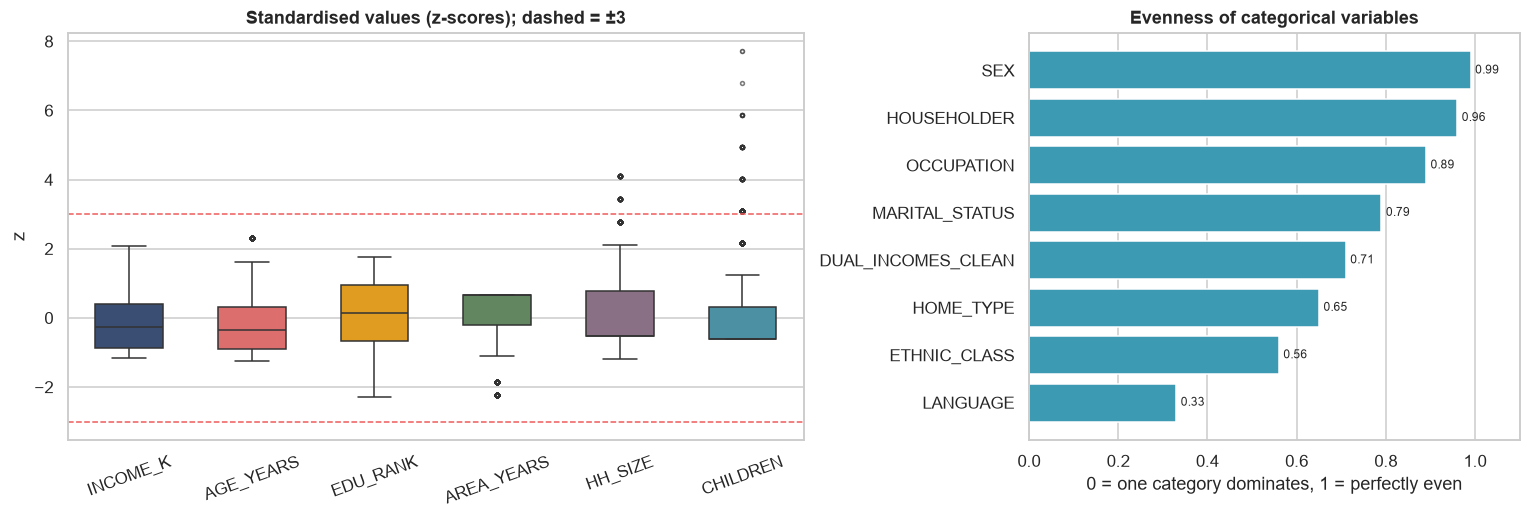

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1.5, 1]})

z_scores = ((data[cont_cols] - data[cont_cols].mean()) / data[cont_cols].std()).melt(
    var_name="variable", value_name="z").dropna()
sns.boxplot(data=z_scores, x="variable", y="z", palette=PALETTE, width=0.55,
            flierprops={"markersize": 2.5, "alpha": 0.4}, ax=axes[0])
axes[0].axhline(3, color=RED, linestyle="--", linewidth=1)
axes[0].axhline(-3, color=RED, linestyle="--", linewidth=1)
axes[0].set_title("Standardised values (z-scores); dashed = ±3")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)

even = cat_summary["evenness_0_to_1"].sort_values()
bars = axes[1].barh(even.index, even.values, color=TEAL)
axes[1].bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
axes[1].set_xlim(0, 1.1)
axes[1].set_title("Evenness of categorical variables")
axes[1].set_xlabel("0 = one category dominates, 1 = perfectly even")
axes[1].grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

- On one common scale, only `HH_SIZE` and `CHILDREN` have points beyond +3; income and education have no outliers at all.
- `LANGUAGE` (evenness 0.33, 91% English) and `ETHNIC_CLASS` (0.56, 65% White) are dominated by one category, so comparisons between their groups rest on small groups.
- `SEX` and `HOUSEHOLDER` are almost perfectly balanced. The chi-square test showed the 55 / 45 split between women and men is still significantly different from 50 / 50.

## **11. 2D Statistical Analysis (two variables at a time)**

The right measure depends on the type of the two variables:

| Pair of variables | Measures and tests used |
|---|---|
| numeric - numeric | covariance, Pearson, Spearman and Kendall correlation, simple regression |
| categorical - categorical | contingency table, chi-square test of independence, Cramér's V |
| numeric - categorical | t-test, Mann-Whitney U, one-way ANOVA, Kruskal-Wallis, effect sizes |

### 11.1 Covariance matrix

Covariance shows whether two variables move together (positive) or in opposite directions (negative). Its size depends on the units, so it cannot be used to compare strength. That is why correlation is used next.

In [40]:
data[cont_cols].cov().round(2)

,INCOME_K,AGE_YEARS,EDU_RANK,AREA_YEARS,HH_SIZE,CHILDREN
INCOME_K,651.12,122.96,13.54,8.90,-0.76,-1.68
AGE_YEARS,122.96,234.83,5.85,12.57,-6.22,-3.87
EDU_RANK,13.54,5.85,1.53,-0.29,-0.51,-0.36
AREA_YEARS,8.90,12.57,-0.29,15.78,0.37,0.27
HH_SIZE,-0.76,-6.22,-0.51,0.37,2.29,1.15
CHILDREN,-1.68,-3.87,-0.36,0.27,1.15,1.17


### 11.2 Correlation with income, with significance tests

- **Pearson r** measures a straight-line relationship.
- **Spearman ρ** and **Kendall τ** use ranks, so they measure any steadily increasing or decreasing relationship and suit banded data better.
- H₀ for each test: the correlation is zero.

In [41]:
rows = []
for c in ["OWNS_HOME", "EDU_RANK", "AGE_YEARS", "DUAL", "AREA_YEARS", "CHILDREN", "HH_SIZE"]:
    pair = data[["INCOME_K", c]].dropna()
    r, p_r = stats.pearsonr(pair[c], pair["INCOME_K"])
    rho, p_rho = stats.spearmanr(pair[c], pair["INCOME_K"])
    tau, p_tau = stats.kendalltau(pair[c], pair["INCOME_K"])
    rows.append({
        "variable": c,
        "pearson_r": round(r, 3), "pearson_p": pval(p_r),
        "spearman_rho": round(rho, 3), "spearman_p": pval(p_rho),
        "kendall_tau": round(tau, 3), "kendall_p": pval(p_tau),
        "strength": strength(rho),
    })

corr_tests = pd.DataFrame(rows).set_index("variable")
corr_tests

,pearson_r,pearson_p,spearman_rho,spearman_p,kendall_tau,kendall_p,strength
variable,,,,,,,
OWNS_HOME,0.473,< 0.001,0.481,< 0.001,0.415,< 0.001,moderate
EDU_RANK,0.430,< 0.001,0.452,< 0.001,0.366,< 0.001,moderate
AGE_YEARS,0.314,< 0.001,0.446,< 0.001,0.354,< 0.001,moderate
DUAL,0.353,< 0.001,0.363,< 0.001,0.314,< 0.001,moderate
AREA_YEARS,0.087,< 0.001,0.087,< 0.001,0.070,< 0.001,very weak
CHILDREN,-0.061,< 0.001,-0.082,< 0.001,-0.067,< 0.001,very weak
HH_SIZE,-0.020,0.062,-0.035,< 0.001,-0.023,0.005,very weak


- Every variable except `HH_SIZE` under Pearson (p = 0.062) is significantly correlated with income. With about 9,000 rows even tiny correlations become significant, so the **size** of the coefficient matters more than the p-value.
- **Home ownership, education, age and dual income** have moderate relationships with income. The other three are very weak.
- For age, Spearman (0.446) is much higher than Pearson (0.314). Pearson only detects straight lines, and the age-income relationship is curved, as the next section shows.
- Kendall τ is always a little smaller than Spearman ρ. That is expected, since the two are measured on different scales.

### 11.3 Simple regression

A regression line gives the size of the effect, not just its strength. Income is regressed on education (straight line), and on age with a straight line and a quadratic curve, because Phase 1 showed income rises and then falls with age.

In [42]:
edu_fit = stats.linregress(data["EDU_RANK"], data["INCOME_K"])
print("Income vs education")
print(f"  INCOME_K = {edu_fit.intercept:.2f} + {edu_fit.slope:.2f} x EDU_RANK")
print(f"  R-squared = {edu_fit.rvalue ** 2:.3f}, p-value = {pval(edu_fit.pvalue)}")


def r_squared(y, y_hat):
    return 1 - ((y - y_hat) ** 2).sum() / ((y - y.mean()) ** 2).sum()


age, inc = data["AGE_YEARS"], data["INCOME_K"]
lin_coef = np.polyfit(age, inc, 1)
quad_coef = np.polyfit(age, inc, 2)
peak_age = -quad_coef[1] / (2 * quad_coef[0])

print()
print("Income vs age")
print(f"  Straight line R-squared = {r_squared(inc, np.polyval(lin_coef, age)):.3f}")
print(f"  Quadratic     R-squared = {r_squared(inc, np.polyval(quad_coef, age)):.3f}")
print(f"  Quadratic curve peaks at age {peak_age:.1f}")

Income vs education
  INCOME_K = 0.40 + 8.88 x EDU_RANK
  R-squared = 0.185, p-value = < 0.001

Income vs age
  Straight line R-squared = 0.099
  Quadratic     R-squared = 0.207
  Quadratic curve peaks at age 48.5


### Plot 12 - Regression lines

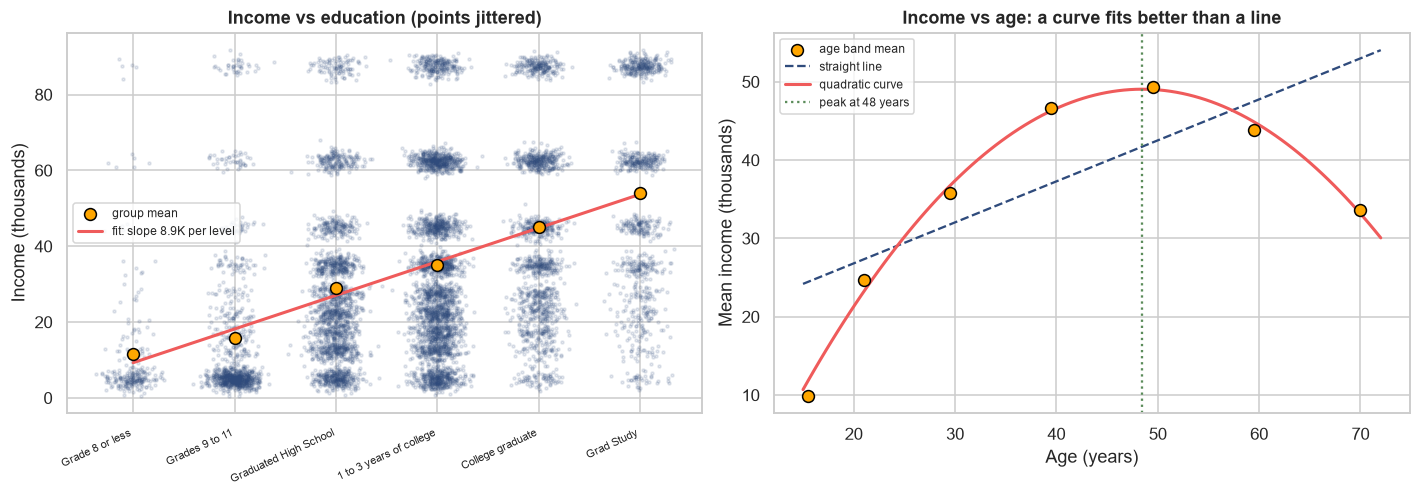

In [43]:
rng = np.random.default_rng(23)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].scatter(data["EDU_RANK"] + rng.normal(0, 0.12, len(data)),
                data["INCOME_K"] + rng.normal(0, 1.5, len(data)), s=4, alpha=0.12, color=BLUE)
edu_means = data.groupby("EDU_RANK")["INCOME_K"].mean()
axes[0].scatter(edu_means.index, edu_means.values, s=60, color=GOLD, edgecolor="black", zorder=3, label="group mean")
xs = np.linspace(1, 6, 50)
axes[0].plot(xs, edu_fit.intercept + edu_fit.slope * xs, color=RED, linewidth=2,
             label=f"fit: slope {edu_fit.slope:.1f}K per level")
axes[0].set_xticks(range(1, 7))
axes[0].set_xticklabels(edu_order, rotation=25, ha="right", fontsize=7.5)
axes[0].set_ylabel("Income (thousands)")
axes[0].set_title("Income vs education (points jittered)")
axes[0].legend(fontsize=8)

age_means = data.groupby("AGE_YEARS")["INCOME_K"].mean()
xs = np.linspace(15, 72, 100)
axes[1].scatter(age_means.index, age_means.values, s=60, color=GOLD, edgecolor="black", zorder=3, label="age band mean")
axes[1].plot(xs, np.polyval(lin_coef, xs), color=BLUE, linestyle="--", label="straight line")
axes[1].plot(xs, np.polyval(quad_coef, xs), color=RED, linewidth=2, label="quadratic curve")
axes[1].axvline(peak_age, color=GREEN, linestyle=":", label=f"peak at {peak_age:.0f} years")
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("Mean income (thousands)")
axes[1].set_title("Income vs age: a curve fits better than a line")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

- Each step up in education adds about **8.9K** to expected income. Education alone explains **18.5%** of the variation in income (R² = 0.185).
- For age, a straight line explains only 9.9% of the variation, but a quadratic curve explains **20.7%**, more than twice as much. Income peaks at about **48 years** and then falls towards retirement. A straight line cannot capture this inverted-U shape.

### 11.4 Categorical vs categorical - chi-square test and Cramér's V

The **chi-square test of independence** compares the observed contingency table with the table expected if the two variables were unrelated. H₀: the two variables are independent.

With almost 9,000 rows even tiny differences become significant, so **Cramér's V** (0 = no association, 1 = perfect association) is reported to show how strong the association actually is. The test also assumes expected counts of at least 5, so the share of cells below 5 is shown.

In [44]:
def chi_square_test(a, b):
    table = pd.crosstab(data[a], data[b])
    chi2, p, dof, expected = stats.chi2_contingency(table)
    v = np.sqrt(chi2 / (table.values.sum() * (min(table.shape) - 1)))
    return chi2, p, dof, v, (expected < 5).mean() * 100


rows = []
for c in ["EDUCATION", "AGE", "OCCUPATION", "HOUSEHOLDER", "MARITAL_STATUS", "HOME_TYPE",
          "DUAL_INCOMES_CLEAN", "ETHNIC_CLASS", "LANGUAGE", "SEX"]:
    chi2, p, dof, v, low = chi_square_test("INCOME_BAND", c)
    rows.append({"INCOME_BAND vs": c, "chi_square": round(chi2, 1), "dof": dof, "p_value": pval(p),
                 "cramers_v": round(v, 3), "cells_expected<5_%": round(low, 1)})

chi_table = pd.DataFrame(rows).set_index("INCOME_BAND vs").sort_values("cramers_v", ascending=False)
chi_table

,chi_square,dof,p_value,cramers_v,cells_expected<5_%
INCOME_BAND vs,,,,,
HOUSEHOLDER,3761.5,16,< 0.001,0.458,0.0
AGE,4274.8,48,< 0.001,0.282,0.0
EDUCATION,3206.3,40,< 0.001,0.267,0.0
MARITAL_STATUS,2498.0,32,< 0.001,0.264,0.0
DUAL_INCOMES_CLEAN,1881.5,24,< 0.001,0.264,0.0
OCCUPATION,3814.0,64,< 0.001,0.231,0.0
HOME_TYPE,852.7,32,< 0.001,0.154,0.0
LANGUAGE,166.7,16,< 0.001,0.096,0.0
ETHNIC_CLASS,355.8,56,< 0.001,0.075,12.5


### Plot 13 - Cramér's V between every pair of categorical variables

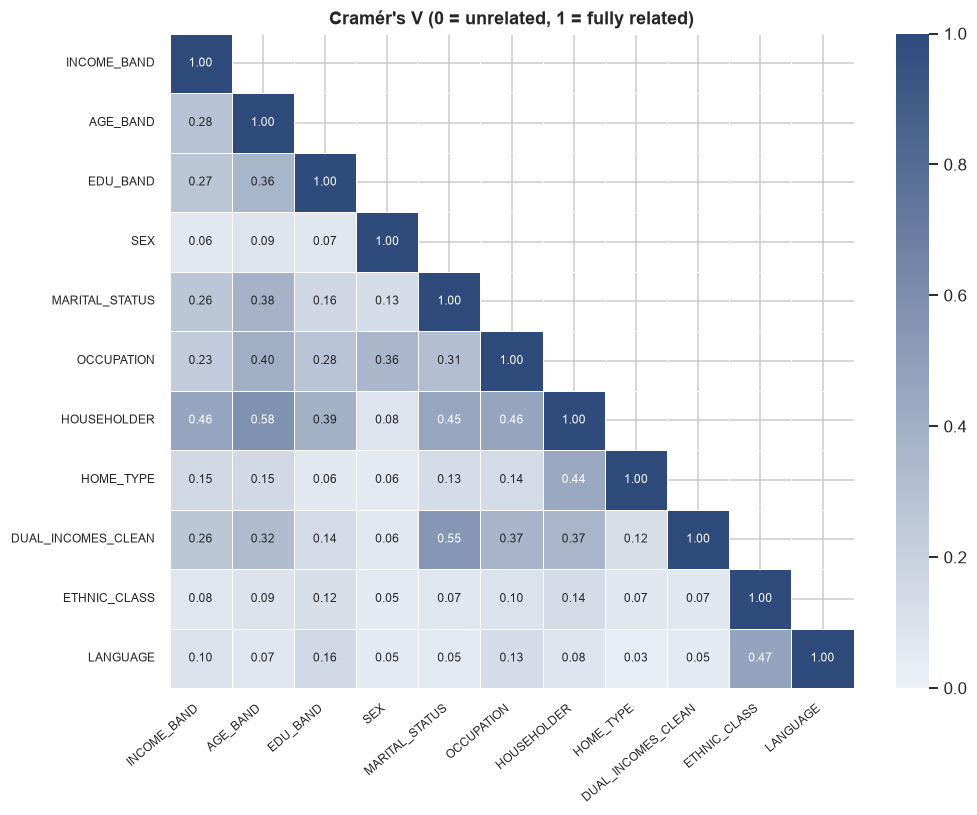

In [45]:
assoc_cols = ["INCOME_BAND", "AGE_BAND", "EDU_BAND"] + cat_cols
cramers = pd.DataFrame(index=assoc_cols, columns=assoc_cols, dtype=float)
for a in assoc_cols:
    for b in assoc_cols:
        cramers.loc[a, b] = 1.0 if a == b else chi_square_test(a, b)[3]

plt.figure(figsize=(9.5, 7.5))
sns.heatmap(cramers, mask=np.triu(np.ones_like(cramers, dtype=bool), k=1), annot=True, fmt=".2f",
            cmap=SEQ, vmin=0, vmax=1, linewidths=0.5, linecolor="white", annot_kws={"size": 8})
plt.title("Cramér's V (0 = unrelated, 1 = fully related)")
plt.xticks(rotation=40, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

- Every chi-square test rejects independence (p < 0.001), but Cramér's V shows very different strengths. Income is linked most strongly to **housing status** (V = 0.46), moderately to age, education, marital status and dual income (0.26-0.28), and hardly at all to sex, ethnicity and language (below 0.10).
- For `ETHNIC_CLASS`, 12.5% of cells have an expected count below 5. That is under the usual 20% limit, so the test is still valid.
- The strongest pairs in the heatmap are **age band - housing status** (0.58: young people live with family, older people own), **marital status - dual incomes** (0.55, as expected, since only couples can have two incomes) and **ethnicity - language** (0.47).
- `LANGUAGE` is barely related to anything except ethnicity.

### 11.5 Numeric vs categorical - comparing income across groups

- **Two groups** (sex): Welch t-test compares the means without assuming equal variances. Mann-Whitney U compares the distributions using ranks, which suits non-normal data. **Cohen's d** gives the effect size (0.2 small, 0.5 medium, 0.8 large).
- **More than two groups**: one-way ANOVA compares means, Kruskal-Wallis is its rank-based version. **Eta squared (η²)** is the share of income variance explained by the grouping (0.01 small, 0.06 medium, 0.14 large).

In [46]:
men = data.loc[data["SEX"] == "M", "INCOME_K"]
women = data.loc[data["SEX"] == "F", "INCOME_K"]

t, p_t = stats.ttest_ind(men, women, equal_var=False)
u, p_u = stats.mannwhitneyu(men, women)
pooled_sd = np.sqrt(((len(men) - 1) * men.var() + (len(women) - 1) * women.var()) / (len(men) + len(women) - 2))
cohens_d = (men.mean() - women.mean()) / pooled_sd

print(f"Mean income: men {men.mean():.2f}K, women {women.mean():.2f}K")
print(f"Welch t-test: t = {t:.2f}, p = {pval(p_t)}")
print(f"Mann-Whitney U: U = {u:.0f}, p = {pval(p_u)}")
print(f"Cohen's d = {cohens_d:.3f}")

Mean income: men 35.48K, women 33.67K
Welch t-test: t = 3.33, p = < 0.001
Mann-Whitney U: U = 10417220, p = < 0.001
Cohen's d = 0.071


In [47]:
rows = []
for c in ["OCCUPATION", "MARITAL_STATUS", "HOUSEHOLDER", "HOME_TYPE", "DUAL_INCOMES_CLEAN", "ETHNIC_CLASS", "LANGUAGE"]:
    groups = [g["INCOME_K"].values for _, g in data.groupby(c)]
    f, p_f = stats.f_oneway(*groups)
    h, p_h = stats.kruskal(*groups)
    ss_between = sum(len(g) * (g.mean() - data["INCOME_K"].mean()) ** 2 for g in groups)
    ss_total = ((data["INCOME_K"] - data["INCOME_K"].mean()) ** 2).sum()
    rows.append({"income by": c, "groups": len(groups), "anova_F": round(f, 1), "anova_p": pval(p_f),
                 "kruskal_H": round(h, 1), "kruskal_p": pval(p_h), "eta_squared": round(ss_between / ss_total, 3)})

anova_table = pd.DataFrame(rows).set_index("income by").sort_values("eta_squared", ascending=False)
anova_table

,groups,anova_F,anova_p,kruskal_H,kruskal_p,eta_squared
income by,,,,,,
HOUSEHOLDER,3,1407.1,< 0.001,2413.9,< 0.001,0.239
MARITAL_STATUS,5,576.2,< 0.001,2108.3,< 0.001,0.205
OCCUPATION,9,263.0,< 0.001,2163.8,< 0.001,0.190
DUAL_INCOMES_CLEAN,4,676.9,< 0.001,1818.7,< 0.001,0.185
HOME_TYPE,5,142.6,< 0.001,452.1,< 0.001,0.060
ETHNIC_CLASS,8,41.8,< 0.001,263.5,< 0.001,0.032
LANGUAGE,3,64.5,< 0.001,143.3,< 0.001,0.014


### Plot 14 - Mean income by group with 95% confidence intervals

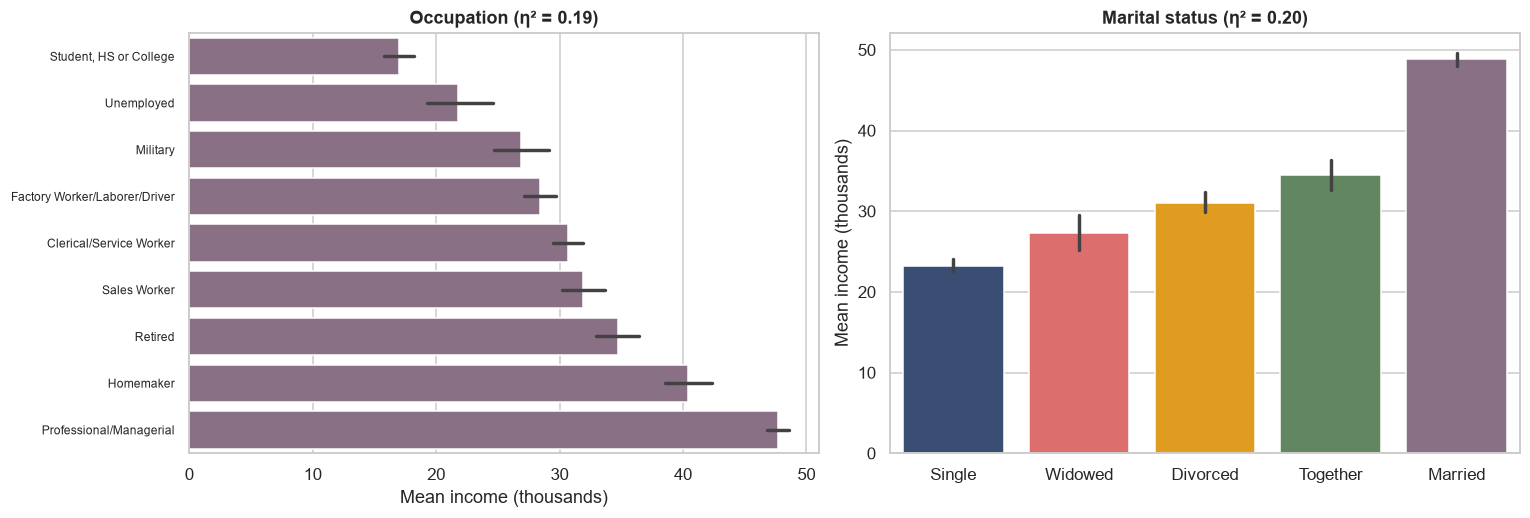

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

occ_order = data.groupby("OCCUPATION")["INCOME_K"].mean().sort_values().index
sns.barplot(data=data, y="OCCUPATION", x="INCOME_K", order=occ_order, color=PURPLE,
            errorbar=("ci", 95), ax=axes[0])
axes[0].set_title(f"Occupation (η² = {anova_table.loc['OCCUPATION', 'eta_squared']:.2f})")
axes[0].set_xlabel("Mean income (thousands)")
axes[0].set_ylabel("")
axes[0].tick_params(axis="y", labelsize=8)

mar_order = data.groupby("MARITAL_STATUS")["INCOME_K"].mean().sort_values().index
sns.barplot(data=data, x="MARITAL_STATUS", y="INCOME_K", order=mar_order, palette=PALETTE,
            errorbar=("ci", 95), ax=axes[1])
axes[1].set_title(f"Marital status (η² = {anova_table.loc['MARITAL_STATUS', 'eta_squared']:.2f})")
axes[1].set_xlabel("")
axes[1].set_ylabel("Mean income (thousands)")

plt.tight_layout()
plt.show()

- **Sex**: men average 35.5K and women 33.7K. Both tests say the difference is significant, but **Cohen's d = 0.07** is far below "small" (0.2), so the gap has almost no practical importance.
- **All seven groupings** differ significantly under ANOVA and Kruskal-Wallis. The effect sizes are large for **housing status (η² = 0.24), marital status (0.21), occupation (0.19) and dual income (0.19)**, medium for home type (0.06), and small for ethnicity and language.
- Plot 14: professional/managerial households average 47.7K, almost three times students (17.0K). Married households (48.9K) earn about twice as much as single ones (23.3K), largely because they often have two incomes.
- The confidence intervals are narrow for large groups and wide for small groups such as Military.

## **12. 3D Statistical Analysis (three variables together)**

A relationship between two variables can change, shrink or disappear once a third variable is taken into account. This section checks that with:

- three-way tables,
- two-way ANOVA (does the effect of one factor depend on another?),
- partial and stratified correlation (removing the effect of a third variable),
- multiple regression and 3D plots.

### 12.1 Three-way tables

In [49]:
three_way = data.pivot_table(index="EDU_BAND", columns="SEX", values="INCOME_K",
                             aggfunc="mean", observed=True).round(1)
three_way["gap (M - F)"] = three_way["M"] - three_way["F"]
three_way

SEX,F,M,gap (M - F)
EDU_BAND,,,
Grade 8 or less,9.5,15.3,5.8
Grades 9 to 11,14.2,18.2,4.0
Graduated High School,29.5,28.1,-1.4
1 to 3 years of college,35.5,34.6,-0.9
College graduate,45.0,44.9,-0.1
Grad Study,52.0,55.9,3.9


In [50]:
data["INCOME_LEVEL"] = pd.cut(data["INCOME_K"], [0, 25, 50, 100],
                              labels=["Low (< 25K)", "Middle (25-50K)", "High (50K+)"])

ownership = data.pivot_table(index="AGE_BAND", columns="INCOME_LEVEL", values="OWNS_HOME",
                             aggfunc="mean", observed=True).mul(100).round(1)
print("% of households owning their home, by age band and income level")
ownership

% of households owning their home, by age band and income level


INCOME_LEVEL,Low (< 25K),Middle (25-50K),High (50K+)
AGE_BAND,,,
14-17,1.1,13.3,20.5
18-24,6.6,13.2,15.6
25-34,10.0,26.0,56.7
35-44,19.1,49.1,79.4
45-54,41.5,64.9,86.1
55-64,50.3,81.1,93.8
65+,60.7,82.7,92.8


- **Education × sex → income**: the gap between men and women is not constant. Men earn more at the lowest education levels (+5.8K) and in Grad Study (+3.9K), while in the middle levels the gap is close to zero or slightly reversed. Section 12.2 tests whether this is significant.
- **Age × income level → home ownership**: ownership rises with income *in every age band*, and it also rises with age *at every income level*. Among high earners, 57% of 25-34 year olds own a home, compared with 94% of 55-64 year olds. So age and income both drive ownership, which means age has to be controlled when the ownership-income link is measured (Section 12.3).

### 12.2 Two-way ANOVA - education × sex → income

Two-way ANOVA tests three hypotheses at once:

1. Education has no effect on income.
2. Sex has no effect on income.
3. **Interaction**: the effect of education is the same for men and women.

**Partial η²** is the share of variance each term explains after the other terms are accounted for.

In [51]:
two_way = smf.ols("INCOME_K ~ C(EDUCATION) * C(SEX)", data=data).fit()
aov = anova_lm(two_way, typ=2)
aov["partial_eta_sq"] = aov["sum_sq"] / (aov["sum_sq"] + aov.loc["Residual", "sum_sq"])
aov["p_value"] = aov["PR(>F)"].apply(lambda p: pval(p) if pd.notna(p) else "")
aov.loc["Residual", "partial_eta_sq"] = np.nan
aov[["sum_sq", "df", "F", "p_value", "partial_eta_sq"]].round(3)

,sum_sq,df,F,p_value,partial_eta_sq
C(EDUCATION),1087660.164,5.0,411.621,< 0.001,0.187
C(SEX),370.203,1.0,0.701,0.403,0.000
C(EDUCATION):C(SEX),10895.068,5.0,4.123,< 0.001,0.002
Residual,4734097.915,8958.0,NaN,,NaN


### Plot 15 - Interaction plot

If education affected men and women in the same way, the two lines would be parallel.

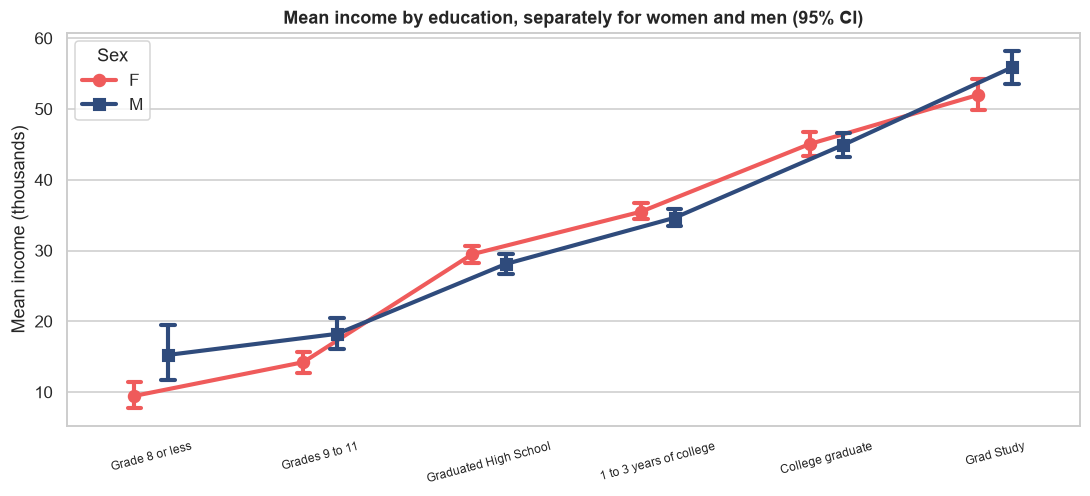

In [52]:
plt.figure(figsize=(10, 4.6))
sns.pointplot(data=data, x="EDU_BAND", y="INCOME_K", hue="SEX", palette=[RED, BLUE],
              errorbar=("ci", 95), dodge=0.2, markers=["o", "s"], capsize=0.08)
plt.title("Mean income by education, separately for women and men (95% CI)")
plt.xlabel("")
plt.ylabel("Mean income (thousands)")
plt.xticks(rotation=15, fontsize=8)
plt.legend(title="Sex")
plt.tight_layout()
plt.show()

- **Education** has a strong, significant effect (F = 411.6, p < 0.001, partial η² = 0.19).
- **Sex** has no significant main effect once education is in the model (p = 0.403). The raw gap of 1.8K in Section 11.5 is partly explained by education: men in this sample are more often college graduates or in grad study (31% of men compared with 25% of women).
- The **interaction** is significant (p < 0.001) but tiny (partial η² = 0.002). In the plot the two lines overlap in the middle levels and only separate at the lowest and highest levels.

### 12.3 Partial correlation - removing the effect of age

Age is linked to income, education, home ownership and household size, so it can create or hide relationships. A **partial correlation** removes age from both variables first: each value has its age band's average subtracted, and the leftovers are correlated.

In [53]:
def partial_corr(x, y, control="AGE"):
    d = data[[x, y, control]].dropna()
    x_left = d[x] - d.groupby(control)[x].transform("mean")
    y_left = d[y] - d.groupby(control)[y].transform("mean")
    return stats.pearsonr(x_left, y_left)


rows = []
for c in ["OWNS_HOME", "EDU_RANK", "DUAL", "HH_SIZE", "CHILDREN", "AREA_YEARS"]:
    pair = data[[c, "INCOME_K"]].dropna()
    r_plain = stats.pearsonr(pair[c], pair["INCOME_K"])[0]
    r_part, p_part = partial_corr(c, "INCOME_K")
    rows.append({"variable vs income": c, "plain_r": round(r_plain, 3), "partial_r (age removed)": round(r_part, 3),
                 "partial_p": pval(p_part), "change": round(r_part - r_plain, 3)})

partial = pd.DataFrame(rows).set_index("variable vs income")
partial

,plain_r,partial_r (age removed),partial_p,change
variable vs income,,,,
OWNS_HOME,0.473,0.356,< 0.001,-0.117
EDU_RANK,0.430,0.264,< 0.001,-0.166
DUAL,0.353,0.249,< 0.001,-0.104
HH_SIZE,-0.020,0.103,< 0.001,0.122
CHILDREN,-0.061,0.034,0.001,0.095
AREA_YEARS,0.087,0.049,< 0.001,-0.038


**Stratified correlation** gives the same idea in another way: the education-income correlation is calculated separately inside each age band.

In [54]:
strata = (data.groupby("AGE_BAND", observed=True)
              .apply(lambda g: pd.Series({"households": len(g),
                                          "spearman_edu_income": g["EDU_RANK"].corr(g["INCOME_K"], method="spearman")}))
              .round(3))
strata["households"] = strata["households"].astype(int)
strata

,households,spearman_edu_income
AGE_BAND,,
14-17,855,0.082
18-24,2129,0.065
25-34,2249,0.280
35-44,1615,0.363
45-54,922,0.291
55-64,640,0.460
65+,560,0.338


**Removing age changes several relationships:**

- **Education → income** falls from 0.43 to 0.26, and **home ownership → income** from 0.47 to 0.36. Part of these links existed only because older people are both more educated or more likely to own and also earn more.
- **Household size → income changes sign**, from −0.02 to **+0.10**, and children from −0.06 to +0.03. This is a **Simpson's paradox**: overall, big households look slightly poorer because many are young people living in large families. Within the same age band, bigger households earn more because they have more earners.

**The stratified correlations confirm this.** For 14-17 and 18-24 year olds, education and income are almost unrelated (0.08 and 0.07). These young people mostly report their family's income, not their own. From age 25 onwards the correlation is 0.28 to 0.46, and it is highest for 55-64.

So a 2D correlation on its own can be misleading. The third variable changes the picture.

### 12.4 Multiple regression

Variables are added one step at a time to see how much each improves the explanation of income. **Adjusted R²** penalises extra variables, so it only rises when a variable truly helps.

In [55]:
formulas = {
    "M1: education": "INCOME_K ~ EDU_RANK",
    "M2: + age": "INCOME_K ~ EDU_RANK + AGE_YEARS",
    "M3: + age squared": "INCOME_K ~ EDU_RANK + AGE_YEARS + I(AGE_YEARS ** 2)",
    "M4: + dual income + sex": "INCOME_K ~ EDU_RANK + AGE_YEARS + I(AGE_YEARS ** 2) + DUAL + C(SEX)",
}
fits = {name: smf.ols(f, data=data).fit() for name, f in formulas.items()}

pd.DataFrame({
    "R_squared": {n: m.rsquared for n, m in fits.items()},
    "adj_R_squared": {n: m.rsquared_adj for n, m in fits.items()},
    "AIC": {n: m.aic for n, m in fits.items()},
}).round(3)

,R_squared,adj_R_squared,AIC
M1: education,0.185,0.185,81740.827
M2: + age,0.221,0.221,81332.774
M3: + age squared,0.260,0.260,80869.784
M4: + dual income + sex,0.308,0.308,80272.839


In [56]:
best = fits["M4: + dual income + sex"]
pd.DataFrame({"coefficient": best.params, "std_error": best.bse,
              "t": best.tvalues, "p_value": best.pvalues.apply(pval)}).round(3)

,coefficient,std_error,t,p_value
Intercept,-22.989,1.455,-15.802,< 0.001
C(SEX)[T.M],1.584,0.452,3.503,< 0.001
EDU_RANK,5.437,0.212,25.646,< 0.001
AGE_YEARS,1.547,0.091,17.017,< 0.001
I(AGE_YEARS ** 2),-0.015,0.001,-13.829,< 0.001
DUAL,13.841,0.558,24.792,< 0.001


- Adjusted R² rises at every step, **0.185 → 0.221 → 0.260 → 0.308**, and AIC falls every time, so each added variable genuinely helps.
- Adding age² gives a clear gain, which confirms the curved age effect from Section 11.3.
- In the full model M4, holding the other variables fixed:
  - one extra education level adds **5.4K**. This is smaller than the 8.9K from simple regression, because part of that effect was really age.
  - having **two incomes adds 13.8K**, the largest single effect.
  - being male adds 1.6K. It is significant here but small, and in Section 12.2 it was not significant, so the sex effect depends on which other variables are controlled.
- About 69% of the variation is still unexplained. That is expected when income is only known in bands and many drivers (such as industry and hours worked) are not in the data.

### Plot 16 - 3D surface: age, education and income

The points are 1,500 randomly chosen households (slightly jittered so they do not stack). The surface is model M3, which uses education, age and age².

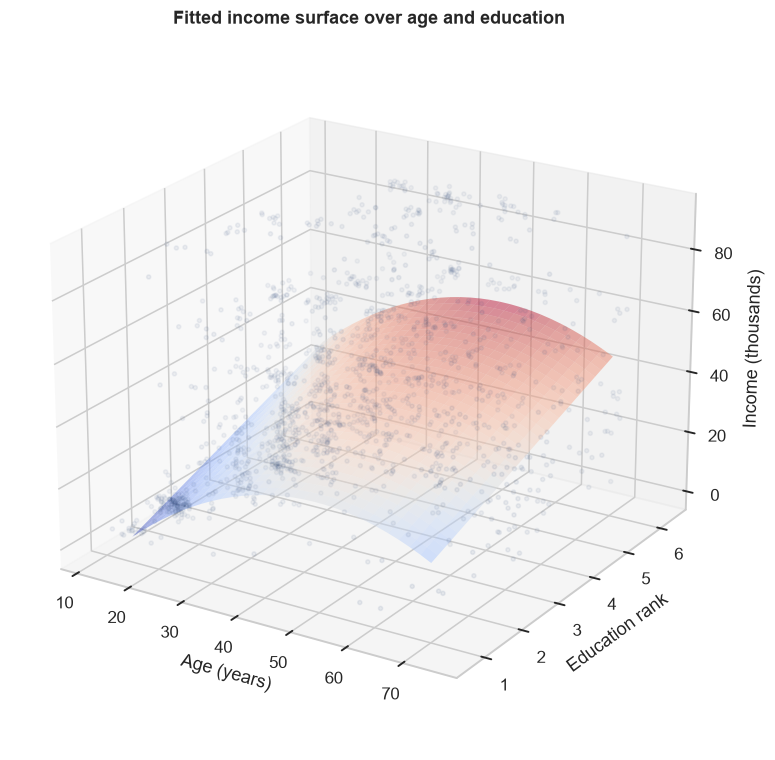

In [57]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3D projection)

rng = np.random.default_rng(23)
pts = data.sample(1500, random_state=23)
m3 = fits["M3: + age squared"]

age_grid, edu_grid = np.meshgrid(np.linspace(15, 70, 30), np.linspace(1, 6, 30))
surface = m3.predict(pd.DataFrame({"AGE_YEARS": age_grid.ravel(), "EDU_RANK": edu_grid.ravel()})).values.reshape(age_grid.shape)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(projection="3d")
ax.scatter(pts["AGE_YEARS"] + rng.normal(0, 1.5, len(pts)), pts["EDU_RANK"] + rng.normal(0, 0.12, len(pts)),
           pts["INCOME_K"] + rng.normal(0, 1.5, len(pts)), color=BLUE, s=7, alpha=0.3)
ax.plot_surface(age_grid, edu_grid, surface, cmap="coolwarm", alpha=0.45, edgecolor="none")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Education rank")
ax.set_zlabel("Income (thousands)")
ax.set_title("Fitted income surface over age and education")
ax.view_init(elev=22, azim=-58)
plt.tight_layout()
plt.show()

### Plot 17 - 3D bar chart: mean income for every age band × education level

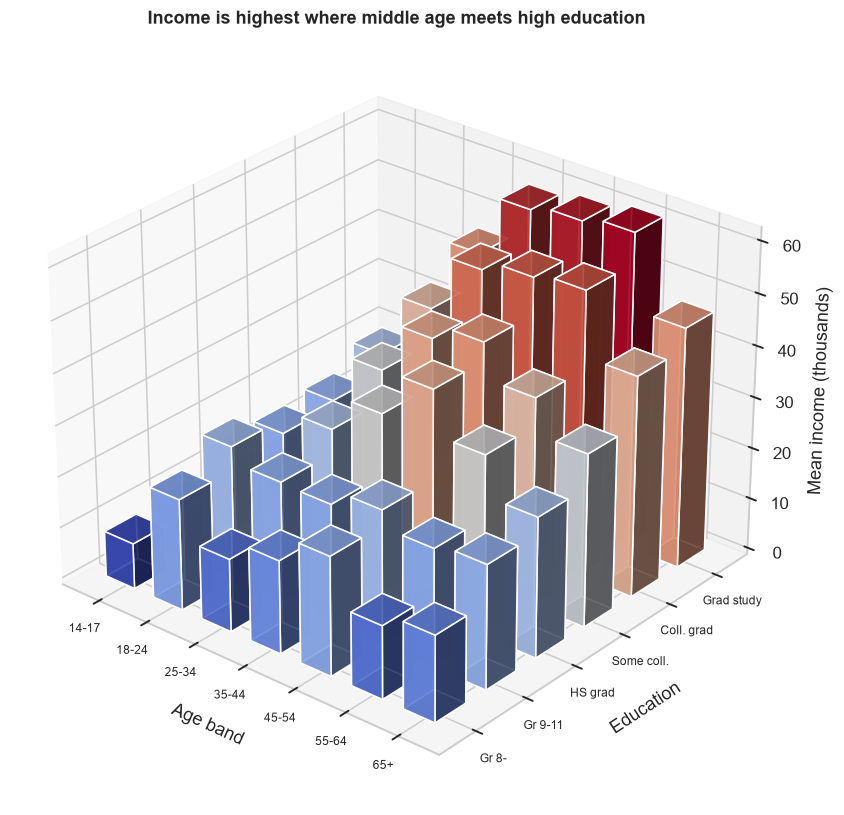

EDU_BAND,Grade 8 or less,Grades 9 to 11,Graduated High School,1 to 3 years of college,College graduate,Grad Study
AGE_BAND,,,,,,
14-17,8.9,10.0,14.4,8.4,NaN,NaN
18-24,21.7,26.3,23.4,24.5,28.5,28.9
25-34,14.2,23.5,28.2,34.3,41.1,46.8
35-44,18.1,23.2,35.0,44.1,52.2,58.7
45-54,23.2,26.2,43.6,47.2,54.3,60.0
55-64,14.2,23.0,35.0,40.4,55.4,61.3
65+,16.8,24.1,27.2,33.6,42.9,46.8


In [58]:
cube = data.pivot_table(index="AGE_BAND", columns="EDU_BAND", values="INCOME_K", aggfunc="mean", observed=True)

xi, yi = np.meshgrid(np.arange(cube.shape[0]), np.arange(cube.shape[1]), indexing="ij")
heights = cube.values.ravel()
colours = plt.cm.coolwarm((heights - np.nanmin(heights)) / (np.nanmax(heights) - np.nanmin(heights)))

fig = plt.figure(figsize=(11, 7.5))
ax = fig.add_subplot(projection="3d")
ax.bar3d(xi.ravel(), yi.ravel(), np.zeros_like(heights), 0.6, 0.6, np.nan_to_num(heights),
         color=colours, shade=True, alpha=0.9)
ax.set_xticks(np.arange(cube.shape[0]) + 0.3)
ax.set_xticklabels(cube.index.astype(str), fontsize=8)
ax.set_yticks(np.arange(cube.shape[1]) + 0.3)
ax.set_yticklabels(["Gr 8-", "Gr 9-11", "HS grad", "Some coll.", "Coll. grad", "Grad study"], fontsize=8)
ax.set_xlabel("Age band", labelpad=8)
ax.set_ylabel("Education", labelpad=10)
ax.set_zlabel("Mean income (thousands)")
ax.set_title("Income is highest where middle age meets high education")
ax.view_init(elev=28, azim=-50)
plt.tight_layout()
plt.show()

cube.round(1)

- At every age, income rises with education (moving along the education axis).
- For every education level, income rises to a peak in middle age (35-64) and falls at 65+ (moving along the age axis).
- The highest mean is **61.3K** for 55-64 year olds with grad study, and the lowest are the 14-17 year olds (about 8-14K). The 14-17 × college cells are empty because those records were removed as impossible in Phase 1.
- Together, Plots 16 and 17 show the same two effects as the regression: education lifts the whole income surface, and age bends it into a hill.

## **13. K-Means Clustering**

K-Means splits the households into *k* groups so that each household is as close as possible to the centre (centroid) of its own group. It repeats two steps until nothing changes:

1. Assign every household to the nearest centroid.
2. Move each centroid to the mean of the households assigned to it.

### 13.1 Feature selection and scaling

Seven numeric features that describe a household are used:

| Feature | Meaning |
|---|---|
| `INCOME_K` | income band midpoint (thousands) |
| `AGE_YEARS` | age band midpoint |
| `EDU_RANK` | education level 1-6 |
| `HH_SIZE` | people in the household |
| `CHILDREN` | people under 18 |
| `OWNS_HOME` | 1 if the home is owned |
| `DUAL` | 1 if there are two incomes |

`AREA_YEARS` is left out because 909 rows have no value and Section 11 showed it is barely linked to anything.

K-Means uses distances, so a variable measured in large numbers (age up to 70) would outweigh one measured in small numbers (0/1). **Standardisation** rescales every feature to mean 0 and standard deviation 1 so they all count equally.

In [59]:
features = ["INCOME_K", "AGE_YEARS", "EDU_RANK", "HH_SIZE", "CHILDREN", "OWNS_HOME", "DUAL"]

scaler = StandardScaler()
X = scaler.fit_transform(data[features])

pd.DataFrame({
    "mean_before": data[features].mean(), "std_before": data[features].std(),
    "mean_after": X.mean(axis=0), "std_after": X.std(axis=0),
}).round(2)

,mean_before,std_before,mean_after,std_after
INCOME_K,34.49,25.52,0.0,1.0
AGE_YEARS,34.67,15.32,0.0,1.0
EDU_RANK,3.84,1.23,-0.0,1.0
HH_SIZE,2.81,1.51,0.0,1.0
CHILDREN,0.66,1.08,0.0,1.0
OWNS_HOME,0.36,0.48,-0.0,1.0
DUAL,0.25,0.43,-0.0,1.0


### 13.2 Choosing the number of clusters (k)

K-Means needs *k* in advance, so k = 2 to 10 are all tried and compared with four measures:

| Measure | Meaning | Better when |
|---|---|---|
| Inertia (WCSS) | total squared distance to the centroids | look for the "elbow" where it stops dropping fast |
| Silhouette | how much closer points are to their own cluster than to the next one (−1 to 1) | higher |
| Davies-Bouldin | average similarity between each cluster and its closest neighbour | lower |
| Calinski-Harabasz | between-cluster spread divided by within-cluster spread | higher |

In [60]:
rows = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=23).fit(X)
    rows.append({"k": k, "inertia": km.inertia_,
                 "silhouette": silhouette_score(X, km.labels_),
                 "davies_bouldin": davies_bouldin_score(X, km.labels_),
                 "calinski_harabasz": calinski_harabasz_score(X, km.labels_),
                 "smallest_cluster_%": np.bincount(km.labels_).min() / len(X) * 100})

k_scores = pd.DataFrame(rows).set_index("k").round(3)
k_scores

,inertia,silhouette,davies_bouldin,calinski_harabasz,smallest_cluster_%
k,,,,,
2,47173.883,0.259,1.625,2968.733,40.323
3,38096.861,0.250,1.435,2906.058,20.725
4,32505.176,0.264,1.370,2784.519,19.220
5,29692.176,0.240,1.414,2498.318,7.258
6,27144.195,0.233,1.414,2354.308,9.376
7,24911.375,0.255,1.412,2271.428,7.001
8,23503.001,0.252,1.360,2140.097,5.641
9,22130.505,0.224,1.425,2057.962,5.496
10,20917.064,0.228,1.348,1992.961,4.916


### Plot 18 - Elbow, silhouette and Davies-Bouldin

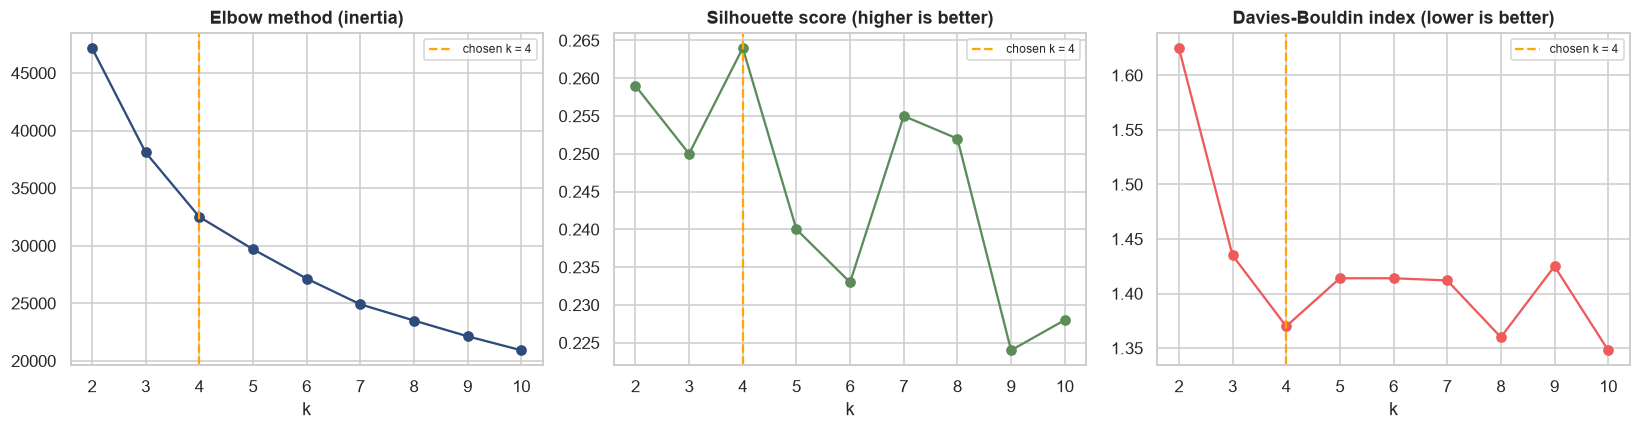

In [61]:
K = 4

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, colour, title in zip(axes, ["inertia", "silhouette", "davies_bouldin"], [BLUE, GREEN, RED],
                                  ["Elbow method (inertia)", "Silhouette score (higher is better)",
                                   "Davies-Bouldin index (lower is better)"]):
    ax.plot(k_scores.index, k_scores[col], marker="o", color=colour)
    ax.axvline(K, color=GOLD, linestyle="--", label=f"chosen k = {K}")
    ax.set_title(title)
    ax.set_xlabel("k")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**k = 4 is chosen** because four measures point to it:

- **Silhouette** is highest at k = 4 (0.264), better than every other k.
- **Davies-Bouldin** is lowest at k = 4 (1.370) for all k up to 7.
- **Elbow**: inertia drops by 9.1K from k = 2 → 3 and by 5.6K from 3 → 4, but only by 2.8K from 4 → 5. So the curve bends at 4.
- **Balance**: the smallest cluster is still 19% of households at k = 4, but it falls to 7% at k = 5.

Calinski-Harabasz is highest at k = 2, but that index is known to favour a small k. A silhouette of 0.26 means the clusters overlap to some degree. That is normal for survey data where most variables are banded.

### 13.3 Final model and cluster profiles

Cluster numbers from K-Means are arbitrary, so they are renumbered from the lowest to the highest mean income. This keeps the labels the same every time the notebook is run.

In [62]:
def number_by_income(labels):
    order = pd.Series(data["INCOME_K"].values).groupby(labels).mean().sort_values().index
    return pd.Series(labels).map({old: new for new, old in enumerate(order)}).values


kmeans = KMeans(n_clusters=K, n_init=10, random_state=23).fit(X)
data["KMEANS"] = number_by_income(kmeans.labels_)

print(f"Silhouette = {silhouette_score(X, data['KMEANS']):.3f}")
print(f"Iterations to converge = {kmeans.n_iter_}")


def profile(label_col):
    prof = data.groupby(label_col)[features].mean()
    prof.insert(0, "households", data[label_col].value_counts().sort_index())
    prof.insert(1, "share_%", prof["households"] / len(data) * 100)
    prof["male_%"] = data.groupby(label_col)["SEX"].apply(lambda s: (s == "M").mean() * 100)
    prof["married_%"] = data.groupby(label_col)["MARITAL_STATUS"].apply(lambda s: (s == "Married").mean() * 100)
    prof["top_occupation"] = data.groupby(label_col)["OCCUPATION"].agg(lambda s: s.mode().iat[0])
    return prof.round(2)


km_profile = profile("KMEANS")
km_profile

Silhouette = 0.264
Iterations to converge = 22


,households,share_%,INCOME_K,AGE_YEARS,EDU_RANK,HH_SIZE,CHILDREN,OWNS_HOME,DUAL,male_%,married_%,top_occupation
KMEANS,,,,,,,,,,,,
0,1724,19.22,18.58,22.11,2.57,4.72,2.06,0.10,0.09,40.66,17.81,"Student, HS or College"
1,3436,38.31,24.84,29.29,3.90,2.08,0.13,0.02,0.03,51.69,8.09,Professional/Managerial
2,1869,20.84,45.97,51.56,4.29,2.21,0.29,0.93,0.00,41.41,50.03,Professional/Managerial
3,1941,21.64,54.65,39.10,4.42,3.01,0.74,0.67,1.00,41.89,92.94,Professional/Managerial


The four clusters are easy to describe:

| Cluster | Share | Profile | Name |
|---|---|---|---|
| 0 | 19% | age ~22, 4.7 people, 2.1 under 18, lowest education, mostly students, income 18.6K | **Young, large families** |
| 1 | 38% | age ~29, 2.1 people, almost nobody owns (2%) or has two incomes (3%), 8% married, income 24.8K | **Young singles, renting** |
| 2 | 21% | age ~52, 93% own their home, no second income, half married (the rest often widowed or divorced), income 46.0K | **Older homeowners, one income** |
| 3 | 22% | age ~39, 100% dual income, 93% married, 67% own, 3 people, highest income 54.7K | **Dual-income couples** |

In [63]:
KM_NAMES = {0: "Young, large families", 1: "Young singles, renting",
            2: "Older homeowners, one income", 3: "Dual-income couples"}
data["KMEANS_NAME"] = data["KMEANS"].map(KM_NAMES)
data["KMEANS_NAME"].value_counts()

KMEANS_NAME
Young singles, renting          3436
Dual-income couples             1941
Older homeowners, one income    1869
Young, large families           1724
Name: count, dtype: int64

### Plot 19 - Clusters on the first two principal components, and cluster profiles

There are seven features, so the clusters cannot be drawn directly. **PCA** (principal component analysis) finds the two directions that keep the most variation and projects every household onto them. The heatmap shows each cluster's average on every feature in standardised units (0 = overall average).

Variance kept by PC1 and PC2: [35.6 24.7] %
Total: 60.4 %


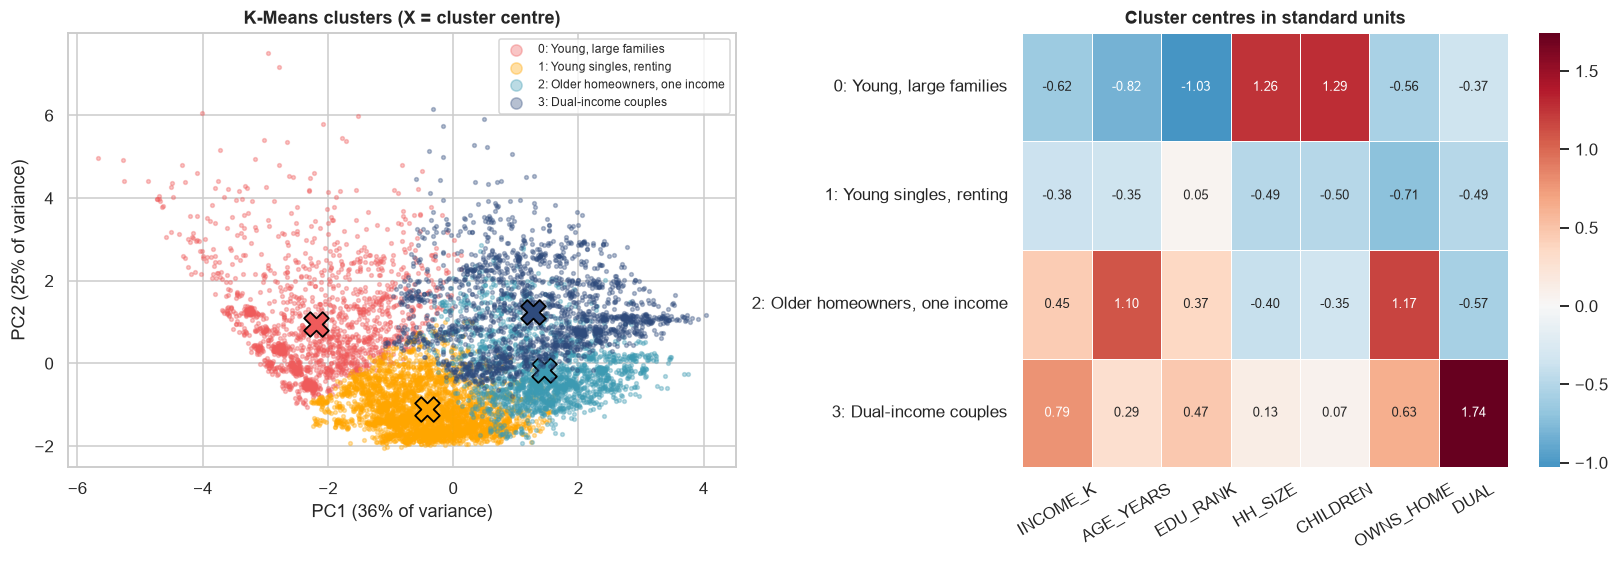

In [64]:
pca = PCA(n_components=2, random_state=23)
pc = pca.fit_transform(X)
print("Variance kept by PC1 and PC2:", (pca.explained_variance_ratio_ * 100).round(1), "%")
print("Total:", round(pca.explained_variance_ratio_.sum() * 100, 1), "%")

CLUSTER_COLOURS = [RED, GOLD, TEAL, BLUE, GREEN, PURPLE]
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={"width_ratios": [1.1, 1]})

jitter = np.random.default_rng(23).normal(0, 0.06, pc.shape)
for c in range(K):
    m = data["KMEANS"].values == c
    axes[0].scatter(pc[m, 0] + jitter[m, 0], pc[m, 1] + jitter[m, 1], s=6, alpha=0.35,
                    color=CLUSTER_COLOURS[c], label=f"{c}: {KM_NAMES[c]}")
    centre = pc[m].mean(axis=0)
    axes[0].scatter(*centre, s=260, marker="X", color=CLUSTER_COLOURS[c], edgecolor="black", linewidth=1.2)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.0f}% of variance)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.0f}% of variance)")
axes[0].set_title("K-Means clusters (X = cluster centre)")
axes[0].legend(fontsize=8, markerscale=3, loc="best")

z_profile = pd.DataFrame(X, columns=features).groupby(data["KMEANS"].values).mean()
z_profile.index = [f"{c}: {KM_NAMES[c]}" for c in z_profile.index]
sns.heatmap(z_profile, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5,
            linecolor="white", annot_kws={"size": 8.5}, ax=axes[1])
axes[1].set_title("Cluster centres in standard units")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Plot 20 - Checking the clusters against variables that were not used

Occupation and marital status were **not** given to K-Means. If the clusters are meaningful, these should still differ clearly between clusters.

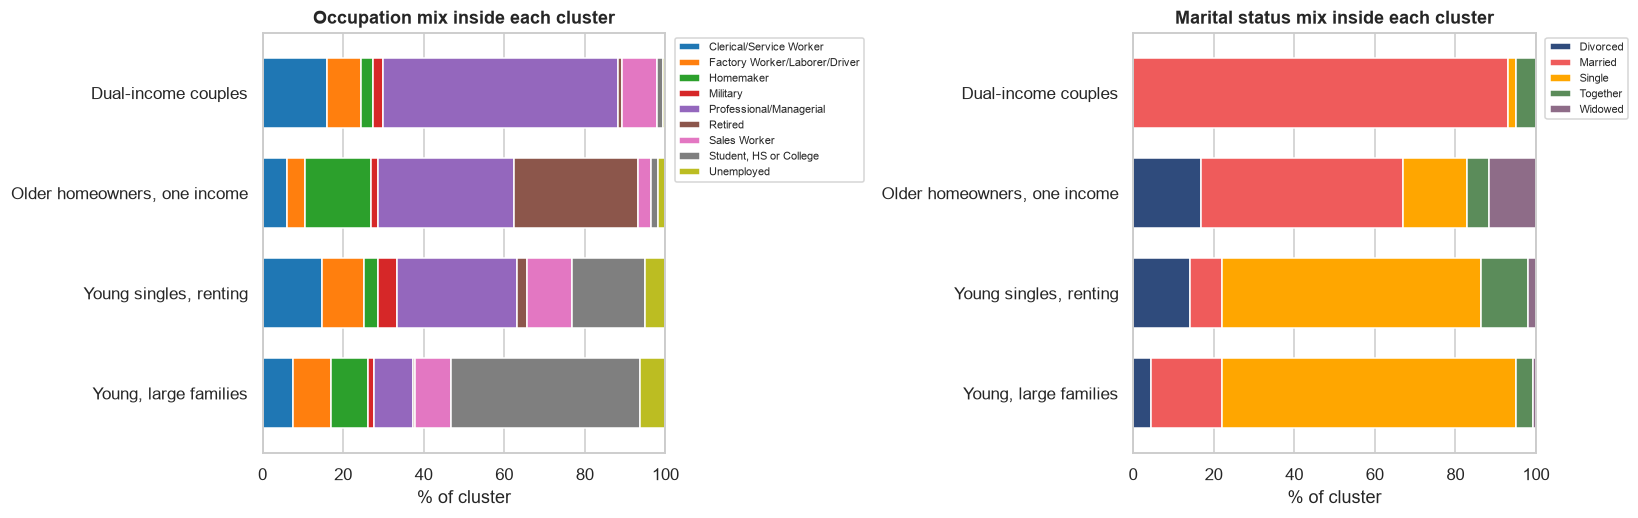

Chi-square test, cluster vs occupation:     Cramer's V = 0.414
Chi-square test, cluster vs marital status: Cramer's V = 0.453


In [65]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

for ax, col, title in zip(axes, ["OCCUPATION", "MARITAL_STATUS"], ["Occupation", "Marital status"]):
    mix = pd.crosstab(data["KMEANS_NAME"], data[col], normalize="index") * 100
    mix = mix.loc[[KM_NAMES[c] for c in range(K)]]
    mix.plot(kind="barh", stacked=True, ax=ax, width=0.7,
             color=sns.color_palette("tab10" if col == "OCCUPATION" else PALETTE, mix.shape[1]))
    ax.set_title(f"{title} mix inside each cluster")
    ax.set_xlabel("% of cluster")
    ax.set_ylabel("")
    ax.set_xlim(0, 100)
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
    ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

print("Chi-square test, cluster vs occupation:     Cramer's V =", round(chi_square_test("KMEANS", "OCCUPATION")[3], 3))
print("Chi-square test, cluster vs marital status: Cramer's V =", round(chi_square_test("KMEANS", "MARITAL_STATUS")[3], 3))

The clusters differ strongly on both variables that K-Means never saw (Cramér's V = 0.41 for occupation and 0.45 for marital status):

- *Young, large families*: almost half are students.
- *Older homeowners, one income*: about 30% retired, with many widowed and divorced people.
- *Dual-income couples*: almost entirely married, and mostly professional/managerial.
- *Young singles, renting*: mostly single, with a mix of jobs.

This supports the conclusion that the clusters are real household types and not just an artefact of the method.

## **14. Hierarchical Clustering**

Agglomerative hierarchical clustering does not need *k* in advance. It starts with every household as its own cluster and repeatedly merges the two closest clusters until only one is left. The full merge history is drawn as a **dendrogram**, and cutting the tree at a chosen height gives the clusters.

How the distance between two *clusters* is measured is called the **linkage**:

| Linkage | Distance between two clusters |
|---|---|
| Single | the closest pair of points |
| Complete | the farthest pair of points |
| Average | the average of all pairs |
| Ward | the increase in within-cluster variance caused by merging (the same goal as K-Means) |

The same seven standardised features `X` from Section 13 are used, on all households.

### 14.1 Ward linkage and the dendrogram

In [66]:
Z_ward = linkage(X, method="ward")

last = Z_ward[-10:, 2][::-1]
merges = pd.DataFrame({"clusters_before_merge": range(2, 12), "merge_height": last})
merges["jump_to_next_merge"] = merges["merge_height"] - merges["merge_height"].shift(-1)
merges.round(2)

,clusters_before_merge,merge_height,jump_to_next_merge
0,2,166.02,46.07
1,3,119.96,1.89
2,4,118.06,40.17
3,5,77.89,10.83
4,6,67.06,8.48
5,7,58.58,6.53
6,8,52.05,0.78
7,9,51.27,3.73
8,10,47.53,1.81
9,11,45.72,NaN


### Plot 21 - Dendrogram and merge heights

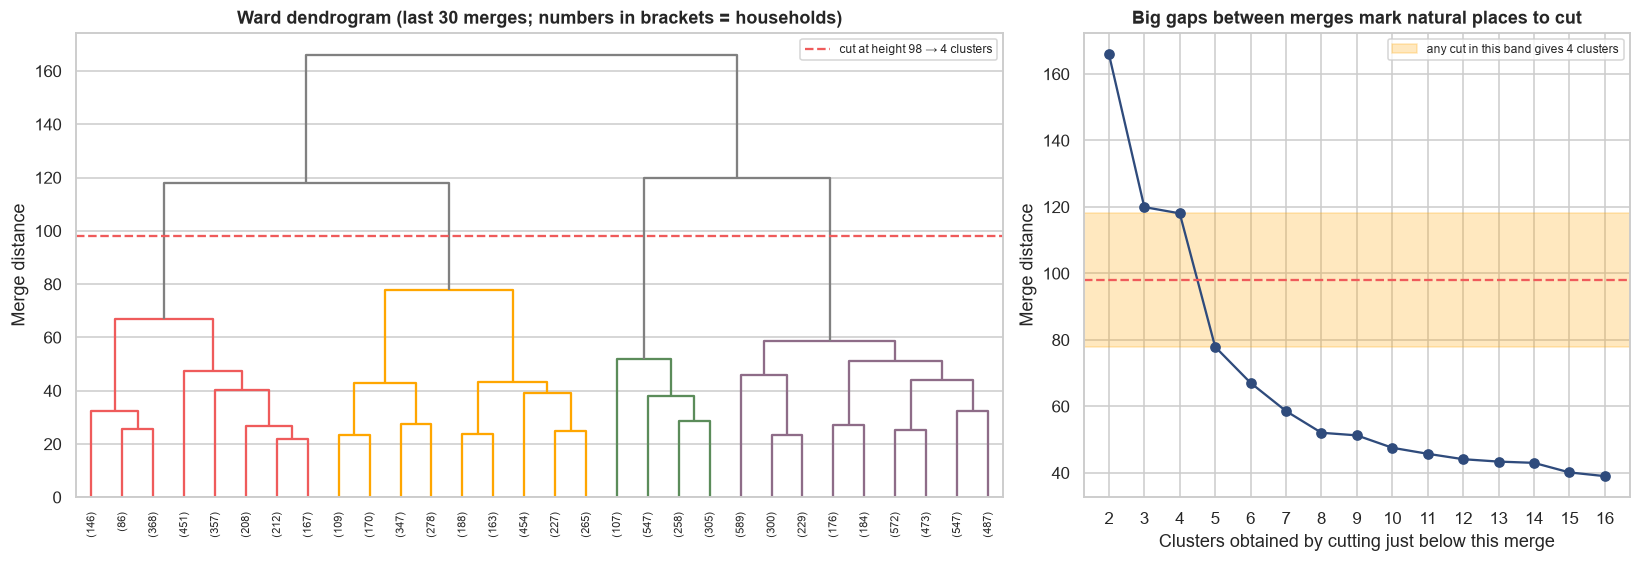

In [67]:
cut_height = (Z_ward[-K, 2] + Z_ward[-(K - 1), 2]) / 2

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={"width_ratios": [1.7, 1]})

dendrogram(Z_ward, truncate_mode="lastp", p=30, color_threshold=cut_height, above_threshold_color="grey",
           show_leaf_counts=True, leaf_rotation=90, leaf_font_size=7.5, ax=axes[0])
axes[0].axhline(cut_height, color=RED, linestyle="--", label=f"cut at height {cut_height:.0f} → {K} clusters")
axes[0].set_title("Ward dendrogram (last 30 merges; numbers in brackets = households)")
axes[0].set_ylabel("Merge distance")
axes[0].legend(fontsize=8)
axes[0].grid(axis="x", visible=False)

heights = Z_ward[-15:, 2][::-1]
axes[1].plot(range(2, 17), heights, marker="o", color=BLUE)
axes[1].axhspan(Z_ward[-K, 2], Z_ward[-(K - 1), 2], color=GOLD, alpha=0.25,
                label=f"any cut in this band gives {K} clusters")
axes[1].axhline(cut_height, color=RED, linestyle="--")
axes[1].set_xlabel("Clusters obtained by cutting just below this merge")
axes[1].set_ylabel("Merge distance")
axes[1].set_title("Big gaps between merges mark natural places to cut")
axes[1].set_xticks(range(2, 17))
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [68]:
rows = []
for k in range(2, 8):
    lab = fcluster(Z_ward, t=k, criterion="maxclust")
    rows.append({"k": k, "silhouette": silhouette_score(X, lab), "davies_bouldin": davies_bouldin_score(X, lab),
                 "smallest_cluster_%": np.bincount(lab)[1:].min() / len(X) * 100})
pd.DataFrame(rows).set_index("k").round(3)

,silhouette,davies_bouldin,smallest_cluster_%
k,,,
2,0.238,1.774,46.778
3,0.207,1.505,13.567
4,0.248,1.453,13.567
5,0.266,1.423,10.078
6,0.266,1.435,6.689
7,0.201,1.584,6.689


- The biggest gap between merge heights is between 1 and 2 clusters (46.1), and the second biggest, almost as large (40.2), is between 3 and 4 clusters. Any cut between heights 77.9 and 118.1 gives **4 clusters**.
- Two clusters would only separate households that own a home or have two incomes from those that do not. That is too coarse to be useful.
- k = 5 and 6 have a slightly higher silhouette (0.266 against 0.248), but the gap below them is much smaller and they create small clusters. k = 4 also allows a direct comparison with K-Means, so **k = 4** is used.

### 14.2 Comparing linkage methods

- **Cophenetic correlation**: how well the tree's merge heights preserve the original distances between households (closer to 1 is better).
- **Silhouette** at k = 4, and the size of the largest cluster, show whether the cut gives useful groups.

In [69]:
distances = pdist(X)

rows = []
for method in ["single", "complete", "average", "ward"]:
    Z = Z_ward if method == "ward" else linkage(X, method=method)
    coph, _ = cophenet(Z, distances)
    lab = fcluster(Z, t=K, criterion="maxclust")
    sizes = np.bincount(lab)[1:]
    rows.append({"linkage": method, "cophenetic_corr": coph, "silhouette_k4": silhouette_score(X, lab),
                 "largest_cluster_%": sizes.max() / len(X) * 100, "cluster_sizes": sorted(sizes, reverse=True)})

linkage_table = pd.DataFrame(rows).set_index("linkage").round(3)
linkage_table

,cophenetic_corr,silhouette_k4,largest_cluster_%,cluster_sizes
linkage,,,,
single,0.547,0.532,99.955,"[8966, 2, 1, 1]"
complete,0.558,0.191,83.489,"[7489, 1356, 114, 11]"
average,0.734,0.368,97.414,"[8738, 219, 10, 3]"
ward,0.559,0.248,39.654,"[3557, 2201, 1995, 1217]"


- **Average linkage** has the best cophenetic correlation (0.73) and silhouette (0.37). But it puts **97%** of households in one cluster, and single linkage puts **99.96%** in one. Both just split off a handful of unusual households. This is the well-known **chaining** problem: clusters grow by absorbing their nearest neighbour one by one.
- **Complete linkage** is better, but one cluster still holds 83% of households.
- **Ward** is the only method that gives four groups of useful size (14% to 40% each). A high silhouette is not enough on its own; the clusters also have to be useful, so **Ward is used**.

### 14.3 Ward cluster profiles

In [70]:
data["WARD"] = number_by_income(fcluster(Z_ward, t=K, criterion="maxclust"))
print(f"Silhouette = {silhouette_score(X, data['WARD']):.3f}")
ward_profile = profile("WARD")
ward_profile

Silhouette = 0.248


,households,share_%,INCOME_K,AGE_YEARS,EDU_RANK,HH_SIZE,CHILDREN,OWNS_HOME,DUAL,male_%,married_%,top_occupation
WARD,,,,,,,,,,,,
0,1217,13.57,11.19,19.16,2.35,4.60,2.02,0.01,0.0,38.78,6.24,"Student, HS or College"
1,3557,39.65,26.59,31.01,3.93,2.19,0.20,0.00,0.0,51.39,7.53,Professional/Managerial
2,1995,22.24,45.34,47.29,4.15,2.55,0.50,0.97,0.0,41.75,48.47,Professional/Managerial
3,2201,24.54,50.32,37.73,4.23,3.08,0.81,0.59,1.0,42.30,91.46,Professional/Managerial


### 14.4 Do K-Means and Ward agree?

The **Adjusted Rand Index (ARI)** compares two groupings of the same rows: 1 = identical, 0 = no better than random.

In [71]:
ari = adjusted_rand_score(data["KMEANS"], data["WARD"])
print(f"Adjusted Rand Index (K-Means vs Ward) = {ari:.3f}")

agree = pd.crosstab(data["KMEANS_NAME"], data["WARD"], rownames=["K-Means"], colnames=["Ward cluster"])
agree = agree.loc[[KM_NAMES[c] for c in range(K)]]
agree

Adjusted Rand Index (K-Means vs Ward) = 0.737


Ward cluster,0,1,2,3
K-Means,,,,
"Young, large families",1135,245,196,148
"Young singles, renting",80,3171,66,119
"Older homeowners, one income",0,140,1729,0
Dual-income couples,2,1,4,1934


### Plot 22 - K-Means and Ward side by side

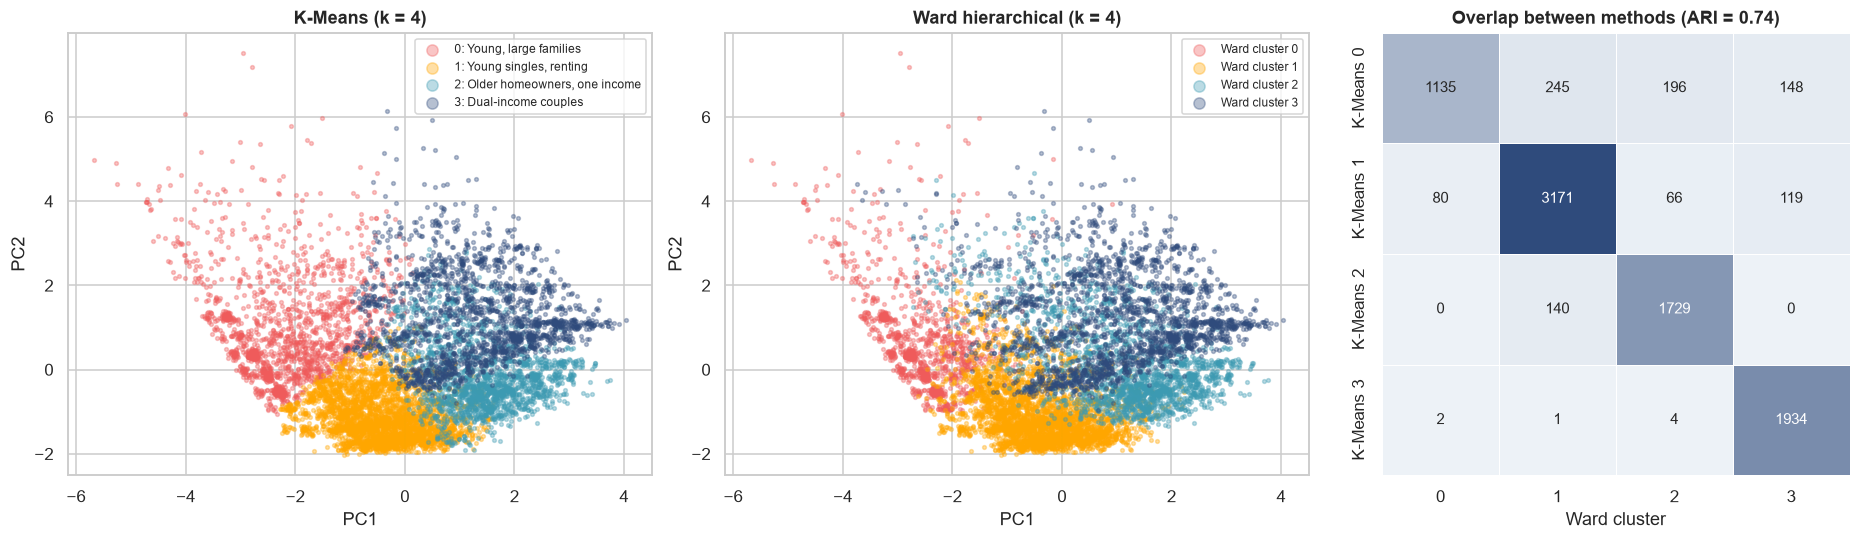

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), gridspec_kw={"width_ratios": [1, 1, 0.8]})

for ax, col, title in zip(axes[:2], ["KMEANS", "WARD"], ["K-Means (k = 4)", "Ward hierarchical (k = 4)"]):
    for c in range(K):
        m = data[col].values == c
        ax.scatter(pc[m, 0] + jitter[m, 0], pc[m, 1] + jitter[m, 1], s=6, alpha=0.35,
                   color=CLUSTER_COLOURS[c], label=f"{c}: {KM_NAMES[c]}" if col == "KMEANS" else f"Ward cluster {c}")
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(fontsize=8, markerscale=3)

sns.heatmap(agree.set_axis([f"K-Means {c}" for c in range(K)]), annot=True, fmt="d", cmap=SEQ,
            linewidths=0.5, linecolor="white", cbar=False, ax=axes[2])
axes[2].set_ylabel("")
axes[2].set_title(f"Overlap between methods (ARI = {ari:.2f})")

plt.tight_layout()
plt.show()

- **ARI = 0.74**, so the two methods agree strongly, even though they work in completely different ways (K-Means moves centres repeatedly, while Ward merges step by step and never undoes a merge).
- *Dual-income couples* is almost identical in both (1,934 of 1,941 households), and *Older homeowners* nearly so (1,729 of 1,869).
- Most of the disagreement is in *Young, large families*. Ward makes this group smaller and purer (1,217 households, mean income 11.2K) and moves borderline households into the other groups.
- The Ward profiles in 14.3 describe the same four household types, so the grouping does not depend on the algorithm.

## **15. Phase 2 Conclusion**

**1D analysis**

1. No numeric variable is normally distributed (all normality tests p < 0.001). Income and age are right-skewed, and household size and children have heavy right tails, so rank-based tests were used alongside the classical ones.
2. The only extreme values are genuine large households (1-2% of rows), and they were kept. The sample has significantly more women (55%) than men.

**2D analysis**

3. Income is most linked to home ownership, education, age and dual income (moderate correlations), and only very weakly to household size, sex, ethnicity and language.
4. Age has a curved effect: income peaks at about 48 years, and a quadratic curve explains twice as much as a straight line.
5. Statistical significance is not the same as importance. The sex difference is significant but has a negligible effect size (d = 0.07).

**3D analysis**

6. Controlling for age reduces the education and ownership effects and **reverses** the household-size effect (Simpson's paradox).
7. Education has no link to income for under-25s, who mostly report their family's income.
8. Education, age (with age²), dual income and sex together explain 31% of the variation in income. Two incomes (+13.8K) is the largest single effect.

**Clustering**

9. K-Means (k = 4, chosen by silhouette, Davies-Bouldin and the elbow) finds four household types: *young large families*, *young singles renting*, *older single-income homeowners* and *dual-income couples*.
10. Ward hierarchical clustering finds the same four types (ARI = 0.74). Single and average linkage fail through chaining.
11. The clusters also separate occupation and marital status, which were not used to build them, so they describe real household types.

**Limitations**

- All numeric values are band midpoints, so every mean, correlation and regression coefficient is an estimate.
- Silhouette values of about 0.25 mean the clusters overlap. They are useful summaries, not sharply separated groups.
- These are associations in one survey. No cause and effect is claimed.